In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
class DGMNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers):
        super(DGMNet, self).__init__()

        self.input = nn.Linear(input_dim, hidden_dim)
        self.hidden = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers)]
        )
        self.output = nn.Linear(hidden_dim, 1)

    def activation(self, x):
        # Swish / SiLU activation (smooth and good for PDEs)
        return x * torch.sigmoid(x)

    def forward(self, t, x):
        # concatenate time and space
        inp = torch.cat([t, x], dim=1)

        h = self.activation(self.input(inp))
        for layer in self.hidden:
            h = self.activation(layer(h))

        return self.output(h)

class PolicyNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers, output_dim):
        super().__init__()

        self.input = nn.Linear(input_dim, hidden_dim)
        self.hidden = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers)]
        )
        self.output = nn.Linear(hidden_dim, output_dim)

    def activation(self, x):
        return x * torch.sigmoid(x)

    def forward(self, t, x):
        inp = torch.cat([t, x], dim=1)
        h = self.activation(self.input(inp))
        for layer in self.hidden:
            h = self.activation(layer(h))
        return self.output(h)

class DeepGalerkinSolver:
    def __init__(self, H, M, C, D, R, sigma,
                 T,
                 alpha_initial,
                 hidden_dim,
                 n_layers,
                 device):

        self.device = device
        self.T = T

        # Convert matrices to tensors
        self.H = torch.tensor(H, dtype=torch.float32, device=self.device)
        self.M = torch.tensor(M, dtype=torch.float32, device=self.device)
        self.C = torch.tensor(C, dtype=torch.float32, device=self.device)
        self.D = torch.tensor(D, dtype=torch.float32, device=self.device)
        self.R = torch.tensor(R, dtype=torch.float32, device=self.device)
        self.sigma = torch.tensor(sigma, dtype=torch.float32, device=self.device)

        self._validate_positive_definite(self.C, "C")
        self._validate_positive_definite(self.R, "R")
        self._validate_strictly_positive_definite(self.D, "D")

        self.dim = self.H.shape[0]

        self.policy_net = DGMNet(self.dim + 1, hidden_dim, n_layers).to(device)

        if alpha_initial is not None:
            self._initialize_policy(alpha_initial)

        self.net = DGMNet(self.dim + 1, hidden_dim, n_layers).to(self.device)

        self.optimizer = optim.Adam(self.net.parameters(), lr=1e-3)

    def _initialize_policy(self, alpha_initial):
      # Simple way: set biases of last layer to alpha_initial
      alpha_initial = torch.tensor(alpha_initial, dtype=torch.float32, device=self.device)
      if self.policy_net.output.bias.shape[0] == 1:
          # If output is scalar, take mean
          self.policy_net.output.bias.data.fill_(alpha_initial.mean())
      else:
          # Otherwise, broadcast
          self.policy_net.output.bias.data[:alpha_initial.shape[0]] = alpha_initial

    def _validate_positive_definite(self, A, name):
        """
        Checks if A is symmetric positive definite.
        Raises ValueError if not.
        """

        # Check symmetry
        if not torch.allclose(A, A.T, atol=1e-6):
            raise ValueError(f"Matrix {name} is not symmetric.")

        # Cholesky test
        try:
            torch.linalg.cholesky(A)
        except RuntimeError:
            raise ValueError(f"Matrix {name} is not positive definite.")

    def _validate_strictly_positive_definite(self, A, name):
        """
        Checks if A is strictly positive definite
        (all eigenvalues strictly > 0).
        """

        # Check symmetry
        if not torch.allclose(A, A.T, atol=1e-6):
            raise ValueError(f"Matrix {name} is not symmetric.")

        # Eigenvalue check
        eigenvalues = torch.linalg.eigvalsh(A)
        min_eig = torch.min(eigenvalues)

        if min_eig <= 0:
            raise ValueError(
                f"Matrix {name} is not strictly positive definite. "
                f"Minimum eigenvalue = {min_eig.item():.6e}"
            )

    def pde_residual(self, t, x):
        t.requires_grad_(True)
        x.requires_grad_(True)

        u = self.net(t, x)

        # Time derivative
        u_t = torch.autograd.grad(
            u, t,
            grad_outputs=torch.ones_like(u),
            create_graph=True
        )[0]

        # First spatial gradient
        grad_u = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            create_graph=True
        )[0]

        # Hessian (loop over dimensions)
        hessian = []
        for i in range(self.dim):
            grad_i = torch.autograd.grad(
                grad_u[:, i],
                x,
                grad_outputs=torch.ones_like(grad_u[:, i]),
                create_graph=True
            )[0]
            hessian.append(grad_i)

        hessian = torch.stack(hessian, dim=2)  # shape: (batch, dim, dim)

        # Diffusion term: 1/2 tr(σσ^T Hessian)
        sigma_sigmaT = self.sigma @ self.sigma.T
        diffusion = 0.5 * torch.einsum("ij,bji->b", sigma_sigmaT, hessian)

        # Drift gradient terms
        Hx = x @ self.H.T
        a = self.policy_net(t,x)
        Malpha = a @ self.M.T

        drift_term = (grad_u * (Hx + Malpha)).sum(dim=1)

        # Quadratic source terms
        quad_x = torch.einsum("bi,ij,bj->b", x, self.C, x)
        quad_alpha = torch.einsum("bi,ij,bj->b", a, self.D, a)

        residual = (
            u_t.squeeze()
            + diffusion
            + drift_term
            + quad_x
            + quad_alpha
        )

        return residual

    def loss(self, batch_size):

        # Sample interior points
        t = torch.rand(batch_size, 1, device=self.device) * self.T
        x = torch.randn(batch_size, self.dim, device=self.device)

        res = self.pde_residual(t, x)
        pde_loss = torch.mean(res**2)

        # Terminal condition
        x_T = torch.randn(batch_size, self.dim, device=self.device)
        t_T = torch.ones(batch_size, 1, device=self.device) * self.T

        u_T = self.net(t_T, x_T)
        target = torch.einsum("bi,ij,bj->b", x_T, self.R, x_T)

        terminal_loss = torch.mean((u_T.squeeze() - target)**2)

        return pde_loss + terminal_loss


    def train(self, epochs=5000, batch_size=256):
      """
      Train the model and record loss history and error against a given Monte Carlo mean.

      Parameters:
          epochs : number of training iterations
          batch_size : batch size for loss evaluation
      Returns:
          loss_history : list of training losses
      """

      self.loss_history = []

      for epoch in range(epochs):
          self.optimizer.zero_grad()

          # Compute loss on batch
          loss = self.loss(batch_size)
          loss.backward()

          self.optimizer.step()

          # Record loss
          self.loss_history.append(loss.item())

          if epoch % 250 == 249:
              print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

      return self.loss_history

def compute_hamiltonian_loss(theta_val_net, theta_act_net, H, M, C, D, batch_size=256, device="cpu"):
    """
    Compute the mean Hamiltonian for a batch of samples.

    Parameters
    ----------
    theta_val_net : nn.Module
         Value function network (fixed parameters).
    theta_act_net : nn.Module
        Policy network (parameters to optimise).
    H, M, C, D : torch.Tensor
        Problem matrices (dim x dim).
    batch_size : int
        Number of samples for estimating Hamiltonian.
    device : str
         'cpu' or 'cuda'.

    Returns
    -------
    torch.Tensor
        Mean Hamiltonian over the batch.
    """
    dim = H.shape[0]
    H = H.to(device)
    M = M.to(device)
    C = C.to(device)
    D = D.to(device)

    # Sample batch points
    t = torch.rand((int(batch_size), 1), device=device)
    x = torch.randn((int(batch_size), dim), device=device)
    x.requires_grad_(True)

    # Value function gradient
    v = theta_val_net(t, x)
    grad_v = torch.autograd.grad(
        v, x, grad_outputs=torch.ones_like(v), create_graph=True
    )[0]  # shape (batch, dim)

    # Current policy
    a = theta_act_net(t, x)  # shape (batch, dim)

    # Hamiltonian: H_i = grad_v^T H x + grad_v^T M a + x^T C x + a^T D a
    ham = (grad_v @ H.T) * x  # grad_v^T H x, shape (batch, dim)
    ham = ham.sum(dim=1)  # sum over dimensions
    ham += (grad_v @ M.T * a).sum(dim=1)  # grad_v^T M a
    ham += torch.einsum("bi,ij,bj->b", x, C, x)  # x^T C x
    ham += torch.einsum("bi,ij,bj->b", a, D, a)  # a^T D a

    return ham.mean()

def policy_improvement(theta_val_net, theta_act_net, H, M, C, D, batch_size=64, device="cpu", lr=1e-3, n_steps=200):
      """
      Perform policy improvement: update theta_act to minimize Hamiltonian.

      Parameters
      ----------
      theta_val_net : nn.Module
          Value function network (fixed parameters).
      theta_act_net : nn.Module
          Policy network to update.
      H, M, C, D : torch.Tensor
          Problem matrices.
      batch_size : int
          Number of points to sample per step.
      device : str
          'cpu' or 'cuda'.
      lr : float
          Learning rate.
      n_steps : int
          Gradient steps to take.

      Returns
      -------
      theta_act_net : nn.Module
          Updated policy network.
      """
      optimizer = torch.optim.Adam(theta_act_net.parameters(), lr=lr)
      theta_val_net.eval()  # freeze value function

      for _ in range(n_steps):
          optimizer.zero_grad()
          loss = compute_hamiltonian_loss(theta_val_net, theta_act_net, H, M, C, D, batch_size, device)
          loss.backward()
          optimizer.step()

      return theta_act_net

if __name__ == "__main__":
  n_iter = 5
  alpha_initial = np.array([1,1])
  H = np.array([[0.5, 0.1], [0.1, 0.3]])
  M = np.array([[1.0, 0.5], [0.0, 1.0]])
  C = np.array([[2.0, 0.5], [0.5, 1.0]])
  D = np.array([[2.0, 0.0], [0.0, 1.0]])
  R = np.array([[1.0, 0.0], [0.0, 2.0]])
  sigma = np.array([[0.3, 0.1], [0.0, 0.2]])

  hidden_dim = 64
  n_layers = 4
  epochs = 5000
  T = 1.0

  device = "cuda" if torch.cuda.is_available() else "cpu"

  def policy_iteration(H, M, C, D, R, sigma, T, alpha_initial, hidden_dim, n_layers, epochs, device, n_iter):
    t_test = torch.tensor([[0.0], [0.5], [1.0]], dtype=torch.float32).to(device)   # (3,1)

    x_test = torch.tensor([
      [1.0, 1.0],
      [0.5, -0.5],
      [0.0, 0.0]
    ], dtype=torch.float32).to(device)  # (3,2)

    # initialise policy network
    policy_net = PolicyNet(input_dim=3, hidden_dim=hidden_dim, n_layers=n_layers, output_dim=2).to(device)

    for k in range(n_iter):

        print(f"\n--- Policy Iteration {k} ---")
        # 1. POLICY EVALUATION
        if k==0:
          solver = DeepGalerkinSolver(
              H, M, C, D, R, sigma,
              T=T,
              alpha_initial=alpha_initial,
              hidden_dim=hidden_dim,
              n_layers=n_layers,
              device=device
          )
        else:
            solver = DeepGalerkinSolver(
              H, M, C, D, R, sigma,
              T=T,
              alpha_initial=None,
              hidden_dim=hidden_dim,
              n_layers=n_layers,
              device=device
          )

        solver.policy_net = policy_net  # inject current policy

        solver.train(epochs)

        # 2. POLICY IMPROVEMENT
        policy_net = policy_improvement(
            theta_val_net=solver.net,   # value function
            theta_act_net=policy_net,
            H=solver.H,
            M=solver.M,
            C=solver.C,
            D=solver.D,
            batch_size=256,
            device=device,
        )
        with torch.no_grad():
          values = solver.net(t_test, x_test)
          controls = policy_net(t_test, x_test)

        for i in range(t_test.shape[0]):
          t_val = t_test[i].item()
          x_val = x_test[i].cpu().numpy()

          v = values[i].item()
          a = controls[i].cpu().numpy()

          print(f"(t={t_val}, x={x_val}) -> value={v:.4f}, control={a}")

    return solver.net, policy_net

  policy_iteration(H=H,
                         M=M,
                         C=C,
                         D=D,
                         R=R,
                         sigma=sigma,
                         T=T,
                         alpha_initial = alpha_initial,
                         hidden_dim=hidden_dim,
                         n_layers=n_layers,
                         epochs=epochs,
                         device=device,
                         n_iter=n_iter)



In [ ]:
# Code from exercise 1.1 to solve Riccati ODE
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LQRSolver:
    """
    Solves the LQR problem via Riccati ODE.

    We want to minimise
        J(t,x) = E[ int_t^T (X'CX + a'Da) ds + X_T' R X_T ],
    subject to
        dX = (HX + Ma) dt + sigma dW,  X_t = x.

    The value function is
        v(t,x) = x'S(t)x + int_t^T tr(sigma sigma' S(r)) dr
    where S solves the Riccati ODE and the optimal control is
        a(t,x) = -D^{-1} M' S(t) x.
    """

    def __init__(self, H, M, C, D, R, sigma, T):
        self.H = np.array(H, dtype=float)
        self.M = np.array(M, dtype=float)
        self.C = np.array(C, dtype=float)
        self.D = np.array(D, dtype=float)
        self.R = np.array(R, dtype=float)
        self.sigma = np.array(sigma, dtype=float)
        self.T = float(T)

        self.d = self.H.shape[0]  # state dimension (coursework uses d=2)

        # precompute these since they're used a lot
        self.D_inv = np.linalg.inv(self.D)
        self.MD_invMT = self.M @ self.D_inv @ self.M.T

        self.S_interp = None
        self.integral_interp = None

    def _riccati_rhs(self, tau, S_flat):
        """
        RHS of the Riccati ODE in forward time (tau = T - t).

        The ODE in original time is
            S'(t) = -2H'S + S M D^{-1} M' S - C,   S(T) = R.

        Substituting tau = T - t flips the sign so we can use a standard
        forward solver
            dS/dtau = 2H'S - S M D^{-1} M' S + C.
        """
        S = S_flat.reshape(self.d, self.d)
        dS = 2.0 * self.H.T @ S - S @ self.MD_invMT @ S + self.C
        return dS.reshape(-1)

    def solve_riccati(self, time_grid):
        """
        Solve the Riccati ODE on the given time grid and build interpolators
        for S(t) and the integral term.

        Args:
            time_grid: array of times in [0, T] (numpy or torch)

        Returns:
            S_values: array of shape (len(time_grid), d, d)
        """
        if isinstance(time_grid, torch.Tensor):
            time_grid = time_grid.detach().cpu().numpy()
        time_grid = np.array(time_grid, dtype=float).reshape(-1)

        if len(time_grid) < 2:
            raise ValueError("time_grid must contain at least two points")
        if np.any(np.diff(time_grid) <= 0):
            raise ValueError("time_grid must be strictly increasing")

        # solve forward in tau = T - t, starting from S(T) = R
        tau_grid = self.T - time_grid  # decreasing in t -> increasing in tau
        sol = solve_ivp(
            self._riccati_rhs,
            (0.0, self.T),
            self.R.reshape(-1),
            t_eval=tau_grid[::-1],  # need increasing tau values
            method="RK45",
            rtol=1e-8,
            atol=1e-10,
        )

        if not sol.success:
            raise RuntimeError(f"Riccati solve failed: {sol.message}")

        # reverse back so columns match increasing t
        S_values = sol.y[:, ::-1].T.reshape(-1, self.d, self.d)

        # enforce symmetry (numerical ODE + interpolation can introduce tiny asymmetry)
        S_values = 0.5 * (S_values + np.transpose(S_values, (0, 2, 1)))

        # build interpolator for S(t)
        kind_S = "cubic" if len(time_grid) >= 4 else "linear"
        self.S_interp = [
            [
                interp1d(
                    time_grid,
                    S_values[:, i, j],
                    kind=kind_S,
                    bounds_error=False,
                    fill_value="extrapolate",
                )
                for j in range(self.d)
            ]
            for i in range(self.d)
        ]

        # compute integral term: int_t^T tr(sigma sigma' S(r)) dr
        # this is the noise-driven part of the value function (doesn't depend on x)
        ss = self.sigma @ self.sigma.T
        trace_vals = np.array([np.trace(ss @ S) for S in S_values], dtype=float)

        # integrate backwards using trapezoid rule
        integral = np.zeros(len(time_grid), dtype=float)
        for i in range(len(time_grid) - 2, -1, -1):
            dt = time_grid[i + 1] - time_grid[i]
            integral[i] = integral[i + 1] + 0.5 * dt * (trace_vals[i] + trace_vals[i + 1])

        # linear is safer for the integral term (avoids cubic overshoot)
        self.integral_interp = interp1d(
            time_grid,
            integral,
            kind="linear",
            bounds_error=False,
            fill_value="extrapolate",
        )

        return S_values

    def _get_S(self, t):
        """Evaluate S(t) at one or more times. Accepts numpy arrays or torch tensors."""
        if self.S_interp is None:
            raise RuntimeError("Call solve_riccati first")

        is_torch = isinstance(t, torch.Tensor)
        t_np = t.detach().cpu().numpy() if is_torch else np.asarray(t, dtype=float)

        shape = t_np.shape
        t_flat = t_np.reshape(-1)

        S_out = np.zeros((len(t_flat), self.d, self.d), dtype=float)
        for i in range(self.d):
            for j in range(self.d):
                S_out[:, i, j] = self.S_interp[i][j](t_flat)

        S_out = S_out.reshape(*shape, self.d, self.d)

        if is_torch:
            return torch.as_tensor(S_out, dtype=t.dtype, device=t.device)
        return S_out

    def value_function(self, t_batch, x_batch):
        """
        Compute v(t, x) = x' S(t) x + int_t^T tr(sigma sigma' S(r)) dr.

        Args:
            t_batch: torch tensor, shape (batch_size,)
            x_batch: torch tensor, shape (batch_size, 1, d)

        Returns:
            v: torch tensor, shape (batch_size, 1)
        """
        if self.S_interp is None or self.integral_interp is None:
            raise RuntimeError("Call solve_riccati first")

        S = self._get_S(t_batch)  # (batch, d, d)
        x = x_batch.squeeze(1)    # (batch, d)

        # quadratic form x' S(t) x
        xSx = torch.sum((x.unsqueeze(1) @ S).squeeze(1) * x, dim=1)

        # integral correction (noise term)
        integral_vals_np = self.integral_interp(t_batch.detach().cpu().numpy())
        integral_vals = torch.as_tensor(integral_vals_np, dtype=t_batch.dtype, device=t_batch.device)

        return (xSx + integral_vals).unsqueeze(1)

    def optimal_control(self, t_batch, x_batch):
        """
        Compute the optimal control a(t, x) = -D^{-1} M' S(t) x.

        Args:
            t_batch: torch tensor, shape (batch_size,)
            x_batch: torch tensor, shape (batch_size, 1, d)

        Returns:
            a: torch tensor, shape (batch_size, d)
        """
        if self.S_interp is None:
            raise RuntimeError("Call solve_riccati first")

        S = self._get_S(t_batch)  # (batch, d, d)
        x = x_batch.squeeze(1)    # (batch, d)

        neg_DinvMT = torch.as_tensor(-self.D_inv @ self.M.T, dtype=t_batch.dtype, device=t_batch.device)

        # compute S(t) x then apply -D^{-1} M'
        Sx = (S @ x.unsqueeze(2)).squeeze(2)           # (batch, d)
        a = (neg_DinvMT @ Sx.unsqueeze(2)).squeeze(2)  # (batch, d)

        return a

if __name__ == "__main__":

    print(f"Using device: {DEVICE}")

    # Use same problem setup matrices as above
    solver = LQRSolver(H, M, C, D, R, sigma, T)
    time_grid = np.linspace(0, T, 1000)
    S_vals = solver.solve_riccati(time_grid)

    print(f"S(0)  =\n{S_vals[0]}")
    print(f"S(T)  =\n{S_vals[-1]}")
    print(f"Terminal error ||S(T) - R|| = {np.linalg.norm(S_vals[-1] - R):.2e}")

    # check value function and control at a few points
    t_test = torch.tensor([0.0, 0.5, 1.0], dtype=torch.float32).to(DEVICE)
    x_test = torch.tensor([[[1.0, 1.0]], [[0.5, -0.5]], [[0.0, 0.0]]], dtype=torch.float32).to(DEVICE)

    v = solver.value_function(t_test, x_test)
    a = solver.optimal_control(t_test, x_test)
    for i in range(3):
        print(f"t={t_test[i]:.1f}, x={x_test[i,0].cpu().numpy()}, v={v[i,0]:.4f}, a={a[i].cpu().numpy()}")

Using device: cpu
Riccati terminal error: 0.00e+00

  Policy iteration step 1 / 5
  [Policy eval] Epoch   500 | Loss: 0.712950
  [Policy eval] Epoch  1000 | Loss: 0.091581
  [Policy eval] Epoch  1500 | Loss: 0.029282
  [Policy eval] Epoch  2000 | Loss: 0.031999
  [Policy eval] Epoch  2500 | Loss: 0.056872
  [Policy eval] Epoch  3000 | Loss: 0.017984
  [Policy eval] Epoch  3500 | Loss: 0.010278
  [Policy eval] Epoch  4000 | Loss: 0.005481
  [Policy eval] Epoch  4500 | Loss: 0.009874
  [Policy eval] Epoch  5000 | Loss: 0.333461
  [Policy impr] Step  100 | Ham loss: -21.922806
  [Policy impr] Step  200 | Ham loss: -26.554239
  [Policy impr] Step  300 | Ham loss: -30.837627
  [Policy impr] Step  400 | Ham loss: -29.027052
  [Policy impr] Step  500 | Ham loss: -31.900360

  Diagnostics after iteration 1:
    t=0.0, x=[1. 1.] | v=46.9971 (true=3.5610, err=43.4361) | a=[-7.0355 -9.2501] (true=[-1.0577 -2.2592])
    t=0.5, x=[ 0.5 -0.5] | v=4.7020 (true=1.0594, err=3.6426) | a=[-1.6493 -0.3282

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/policy_iteration_losses.png'

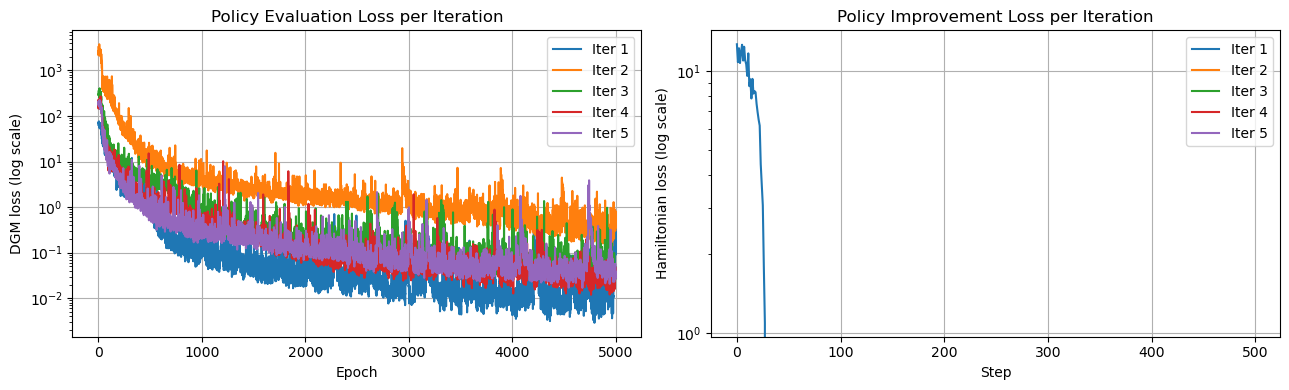

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# ---------------------------------------------------------------------------
# Network architectures
# ---------------------------------------------------------------------------

class DGMNet(nn.Module):
    """
    Simple feedforward network with SiLU activations.
    Used for the value function: input (t, x) -> scalar.
    """
    def __init__(self, input_dim, hidden_dim, n_layers):
        super(DGMNet, self).__init__()
        self.input = nn.Linear(input_dim, hidden_dim)
        self.hidden = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers)]
        )
        self.output = nn.Linear(hidden_dim, 1)

    def activation(self, x):
        return x * torch.sigmoid(x)  # SiLU / Swish

    def forward(self, t, x):
        inp = torch.cat([t, x], dim=1)
        h = self.activation(self.input(inp))
        for layer in self.hidden:
            h = self.activation(layer(h))
        return self.output(h)


class PolicyNet(nn.Module):
    """
    Feedforward network with SiLU activations.
    Used for the control: input (t, x) -> action in R^2.
    """
    def __init__(self, input_dim, hidden_dim, n_layers, output_dim):
        super().__init__()
        self.input = nn.Linear(input_dim, hidden_dim)
        self.hidden = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers)]
        )
        self.output = nn.Linear(hidden_dim, output_dim)

    def activation(self, x):
        return x * torch.sigmoid(x)

    def forward(self, t, x):
        inp = torch.cat([t, x], dim=1)
        h = self.activation(self.input(inp))
        for layer in self.hidden:
            h = self.activation(layer(h))
        return self.output(h)


# ---------------------------------------------------------------------------
# Riccati ODE solver (analytical reference)
# ---------------------------------------------------------------------------

class LQRSolver:
    """
    Solves the LQR problem via the Riccati ODE.

    Value function:  v(t,x) = x' S(t) x + int_t^T tr(sigma sigma' S(r)) dr
    Optimal control: a*(t,x) = -D^{-1} M' S(t) x
    """

    def __init__(self, H, M, C, D, R, sigma, T):
        self.H = np.array(H, dtype=float)
        self.M = np.array(M, dtype=float)
        self.C = np.array(C, dtype=float)
        self.D = np.array(D, dtype=float)
        self.R = np.array(R, dtype=float)
        self.sigma = np.array(sigma, dtype=float)
        self.T = float(T)
        self.d = self.H.shape[0]

        self.D_inv = np.linalg.inv(self.D)
        self.MD_invMT = self.M @ self.D_inv @ self.M.T

        self.S_interp = None
        self.integral_interp = None

    def _riccati_rhs(self, tau, S_flat):
        S = S_flat.reshape(self.d, self.d)
        dS = 2.0 * self.H.T @ S - S @ self.MD_invMT @ S + self.C
        return dS.reshape(-1)

    def solve_riccati(self, time_grid):
        if isinstance(time_grid, torch.Tensor):
            time_grid = time_grid.detach().cpu().numpy()
        time_grid = np.array(time_grid, dtype=float).reshape(-1)

        tau_grid = self.T - time_grid
        sol = solve_ivp(
            self._riccati_rhs,
            (0.0, self.T),
            self.R.reshape(-1),
            t_eval=tau_grid[::-1],
            method="RK45",
            rtol=1e-8,
            atol=1e-10,
        )
        if not sol.success:
            raise RuntimeError(f"Riccati solve failed: {sol.message}")

        S_values = sol.y[:, ::-1].T.reshape(-1, self.d, self.d)
        S_values = 0.5 * (S_values + np.transpose(S_values, (0, 2, 1)))

        kind_S = "cubic" if len(time_grid) >= 4 else "linear"
        self.S_interp = [
            [
                interp1d(time_grid, S_values[:, i, j], kind=kind_S,
                         bounds_error=False, fill_value="extrapolate")
                for j in range(self.d)
            ]
            for i in range(self.d)
        ]

        ss = self.sigma @ self.sigma.T
        trace_vals = np.array([np.trace(ss @ S) for S in S_values], dtype=float)
        integral = np.zeros(len(time_grid), dtype=float)
        for i in range(len(time_grid) - 2, -1, -1):
            dt = time_grid[i + 1] - time_grid[i]
            integral[i] = integral[i + 1] + 0.5 * dt * (trace_vals[i] + trace_vals[i + 1])

        self.integral_interp = interp1d(
            time_grid, integral, kind="linear",
            bounds_error=False, fill_value="extrapolate"
        )
        return S_values

    def _get_S(self, t):
        if self.S_interp is None:
            raise RuntimeError("Call solve_riccati first.")
        is_torch = isinstance(t, torch.Tensor)
        t_np = t.detach().cpu().numpy() if is_torch else np.asarray(t, dtype=float)
        shape = t_np.shape
        t_flat = t_np.reshape(-1)
        S_out = np.zeros((len(t_flat), self.d, self.d), dtype=float)
        for i in range(self.d):
            for j in range(self.d):
                S_out[:, i, j] = self.S_interp[i][j](t_flat)
        S_out = S_out.reshape(*shape, self.d, self.d)
        if is_torch:
            return torch.as_tensor(S_out, dtype=t.dtype, device=t.device)
        return S_out

    def value_function(self, t_batch, x_batch):
        """
        v(t,x) = x' S(t) x + int_t^T tr(sigma sigma' S(r)) dr

        Args:
            t_batch : (batch,)   torch tensor
            x_batch : (batch, 1, d) torch tensor
        Returns:
            v : (batch, 1) torch tensor
        """
        S = self._get_S(t_batch)           # (batch, d, d)
        x = x_batch.squeeze(1)             # (batch, d)
        xSx = torch.sum((x.unsqueeze(1) @ S).squeeze(1) * x, dim=1)
        integral_np = self.integral_interp(t_batch.detach().cpu().numpy())
        integral = torch.as_tensor(integral_np, dtype=t_batch.dtype, device=t_batch.device)
        return (xSx + integral).unsqueeze(1)

    def optimal_control(self, t_batch, x_batch):
        """
        a*(t,x) = -D^{-1} M' S(t) x

        Args:
            t_batch : (batch,)   torch tensor
            x_batch : (batch, 1, d) torch tensor
        Returns:
            a : (batch, d) torch tensor
        """
        S = self._get_S(t_batch)           # (batch, d, d)
        x = x_batch.squeeze(1)             # (batch, d)
        neg_DinvMT = torch.as_tensor(
            -self.D_inv @ self.M.T, dtype=t_batch.dtype, device=t_batch.device
        )
        Sx = (S @ x.unsqueeze(2)).squeeze(2)            # (batch, d)
        a = (neg_DinvMT @ Sx.unsqueeze(2)).squeeze(2)   # (batch, d)
        return a


# ---------------------------------------------------------------------------
# Deep Galerkin solver (policy evaluation step)
# ---------------------------------------------------------------------------

class DeepGalerkinSolver:
    """
    Solves the linear PDE associated with a fixed policy via the DGM loss.

    Given a policy network a(t,x; theta_act), the value function u(t,x)
    satisfies the linear PDE:

        u_t + 1/2 tr(sigma sigma' u_xx)
            + (grad u)' (H x + M a)
            + x' C x + a' D a = 0,   (t,x) in [0,T) x R^2
        u(T,x) = x' R x.
    """

    def __init__(self, H, M, C, D, R, sigma, T, hidden_dim, n_layers, device):
        self.device = device
        self.T = T

        self.H = torch.tensor(H, dtype=torch.float32, device=device)
        self.M = torch.tensor(M, dtype=torch.float32, device=device)
        self.C = torch.tensor(C, dtype=torch.float32, device=device)
        self.D = torch.tensor(D, dtype=torch.float32, device=device)
        self.R = torch.tensor(R, dtype=torch.float32, device=device)
        self.sigma = torch.tensor(sigma, dtype=torch.float32, device=device)

        self.dim = self.H.shape[0]

        self.net = DGMNet(self.dim + 1, hidden_dim, n_layers).to(device)
        self.optimizer = optim.Adam(self.net.parameters(), lr=1e-3)

        # will be injected from outside
        self.policy_net = None

    def pde_residual(self, t, x):
        t = t.detach().requires_grad_(True)
        x = x.detach().requires_grad_(True)

        u = self.net(t, x)

        u_t = torch.autograd.grad(
            u, t, grad_outputs=torch.ones_like(u), create_graph=True
        )[0]

        grad_u = torch.autograd.grad(
            u, x, grad_outputs=torch.ones_like(u), create_graph=True
        )[0]

        hessian = []
        for i in range(self.dim):
            grad_i = torch.autograd.grad(
                grad_u[:, i], x,
                grad_outputs=torch.ones_like(grad_u[:, i]),
                create_graph=True
            )[0]
            hessian.append(grad_i)
        hessian = torch.stack(hessian, dim=2)  # (batch, dim, dim)

        sigma_sigmaT = self.sigma @ self.sigma.T
        diffusion = 0.5 * torch.einsum("ij,bji->b", sigma_sigmaT, hessian)

        Hx = x @ self.H.T
        a = self.policy_net(t, x)
        Malpha = a @ self.M.T

        drift_term = (grad_u * (Hx + Malpha)).sum(dim=1)

        quad_x = torch.einsum("bi,ij,bj->b", x, self.C, x)
        quad_a = torch.einsum("bi,ij,bj->b", a, self.D, a)

        residual = u_t.squeeze() + diffusion + drift_term + quad_x + quad_a
        return residual

    def loss(self, batch_size):
        t = torch.rand(batch_size, 1, device=self.device) * self.T
        x = torch.randn(batch_size, self.dim, device=self.device)
        res = self.pde_residual(t, x)
        pde_loss = torch.mean(res ** 2)

        x_T = torch.randn(batch_size, self.dim, device=self.device)
        t_T = torch.ones(batch_size, 1, device=self.device) * self.T
        u_T = self.net(t_T, x_T)
        target = torch.einsum("bi,ij,bj->b", x_T, self.R, x_T)
        terminal_loss = torch.mean((u_T.squeeze() - target) ** 2)

        return pde_loss + terminal_loss

    def train(self, epochs=5000, batch_size=256):
        self.loss_history = []
        for epoch in range(epochs):
            self.optimizer.zero_grad()
            loss = self.loss(batch_size)
            loss.backward()
            self.optimizer.step()
            self.loss_history.append(loss.item())
            if epoch % 500 == 499:
                print(f"  [Policy eval] Epoch {epoch+1:5d} | Loss: {loss.item():.6f}")
        return self.loss_history


# ---------------------------------------------------------------------------
# Hamiltonian minimisation (policy improvement step)
# ---------------------------------------------------------------------------

def compute_hamiltonian_loss(val_net, act_net, M, D, batch_size=256, device="cpu"):
    """
    Compute the control-dependent part of the Hamiltonian:

        H_a = (grad_v)' M a + a' D a

    where grad_v is detached (treated as a fixed coefficient), so gradients
    flow only through the policy network act_net.

    The full Hamiltonian also contains (grad_v)' H x + x' C x, but these
    terms are independent of the policy and so do not affect the minimiser.
    Including them would add noise to the gradient without helping convergence.
    """
    dim = M.shape[0]
    M = M.to(device)
    D = D.to(device)

    t = torch.rand((batch_size, 1), device=device)
    x = torch.randn((batch_size, dim), device=device)
    x.requires_grad_(True)

    # grad_v treated as a fixed coefficient — detach to avoid differentiating
    # through the value network when we call loss.backward()
    v = val_net(t, x)
    grad_v = torch.autograd.grad(
        v, x, grad_outputs=torch.ones_like(v), create_graph=False
    )[0].detach()

    # policy output; x detached since we only need grads w.r.t. act_net params
    a = act_net(t, x.detach())

    ham = (grad_v @ M.T * a).sum(dim=1)              # (grad_v)' M a
    ham = ham + torch.einsum("bi,ij,bj->b", a, D, a) # a' D a

    return ham.mean()


def policy_improvement(val_net, act_net, M, D,
                        batch_size=256, device="cpu", lr=1e-3, n_steps=500):
    """
    Update act_net to minimise the control-dependent Hamiltonian.
    val_net parameters are frozen throughout.
    """
    optimizer = optim.Adam(act_net.parameters(), lr=lr)
    val_net.eval()

    ham_history = []
    for step in range(n_steps):
        optimizer.zero_grad()
        loss = compute_hamiltonian_loss(val_net, act_net, M, D, batch_size, device)
        loss.backward()
        optimizer.step()
        ham_history.append(loss.item())

        if step % 100 == 99:
            print(f"  [Policy impr] Step {step+1:4d} | Ham loss: {loss.item():.6f}")

    return act_net, ham_history


# ---------------------------------------------------------------------------
# Policy iteration loop
# ---------------------------------------------------------------------------

def policy_iteration(H, M, C, D, R, sigma, T,
                     hidden_dim, n_layers,
                     n_iter, epochs_eval, epochs_impr,
                     batch_size, device,
                     lqr_solver=None):
    """
    Run n_iter steps of policy iteration.

    At each iteration k:
      1. Policy evaluation  — train DGMNet to solve the linear PDE under
                              the current policy, giving v^(k+1).
      2. Policy improvement — update PolicyNet to minimise the Hamiltonian
                              under v^(k+1), giving a^(k+1).

    Args:
        lqr_solver : LQRSolver instance (optional). If provided, the true
                     value v_true and optimal control a* are used as reference
                     at diagnostic points.

    Returns:
        val_net    : trained value network after final iteration
        act_net    : trained policy network after final iteration
        history    : dict with loss curves and diagnostic values per iteration
    """

    # Diagnostic test points — consistent with Section 1.2
    t_test = torch.tensor([[0.0], [0.5], [1.0]], dtype=torch.float32, device=device)
    x_test = torch.tensor(
        [[1.0, 1.0], [0.5, -0.5], [0.0, 0.0]], dtype=torch.float32, device=device
    )

    history = {
        "eval_loss": [],     # list of loss curves, one per iteration
        "ham_loss": [],      # list of Hamiltonian loss curves, one per iteration
        "value_at_test": [], # value net output at test points, per iteration
        "ctrl_at_test": [],  # policy net output at test points, per iteration
    }

    # Initialise policy network with output bias near (1,1) to match the
    # constant policy used in Section 3
    act_net = PolicyNet(
        input_dim=3, hidden_dim=hidden_dim, n_layers=n_layers, output_dim=2
    ).to(device)
    with torch.no_grad():
        act_net.output.bias.data = torch.tensor(
            [1.0, 1.0], dtype=torch.float32, device=device
        )

    for k in range(n_iter):
        print(f"\n{'='*60}")
        print(f"  Policy iteration step {k+1} / {n_iter}")
        print(f"{'='*60}")

        # ------------------------------------------------------------------
        # Step 1: Policy evaluation
        # Solve the linear PDE under the current policy act_net using DGM.
        # ------------------------------------------------------------------
        solver = DeepGalerkinSolver(
            H, M, C, D, R, sigma, T, hidden_dim, n_layers, device
        )
        solver.policy_net = act_net  # inject current policy (frozen during eval)

        # freeze policy during value training
        for p in act_net.parameters():
            p.requires_grad_(False)

        eval_loss = solver.train(epochs=epochs_eval, batch_size=batch_size)
        history["eval_loss"].append(eval_loss)

        # unfreeze policy for improvement step
        for p in act_net.parameters():
            p.requires_grad_(True)

        # ------------------------------------------------------------------
        # Step 2: Policy improvement
        # Update act_net to minimise the control-dependent Hamiltonian
        # under the value network just trained.
        # ------------------------------------------------------------------
        act_net, ham_loss = policy_improvement(
            val_net=solver.net,
            act_net=act_net,
            M=solver.M,
            D=solver.D,
            batch_size=batch_size,
            device=device,
            n_steps=epochs_impr,
        )
        history["ham_loss"].append(ham_loss)

        # ------------------------------------------------------------------
        # Diagnostics: evaluate at test points and compare to Riccati if available
        # ------------------------------------------------------------------
        with torch.no_grad():
            v_pred = solver.net(t_test, x_test).cpu().numpy()
            a_pred = act_net(t_test, x_test).cpu().numpy()

        history["value_at_test"].append(v_pred)
        history["ctrl_at_test"].append(a_pred)

        print(f"\n  Diagnostics after iteration {k+1}:")
        for i in range(t_test.shape[0]):
            t_i = t_test[i, 0].item()
            x_i = x_test[i].cpu().numpy()
            v_i = v_pred[i, 0]
            a_i = a_pred[i]

            if lqr_solver is not None:
                t_np = t_test[:, 0].cpu()
                x_np = x_test.unsqueeze(1).cpu()
                v_true = lqr_solver.value_function(t_np, x_np).numpy()[i, 0]
                a_true = lqr_solver.optimal_control(t_np, x_np).numpy()[i]
                print(
                    f"    t={t_i:.1f}, x={x_i} | "
                    f"v={v_i:.4f} (true={v_true:.4f}, err={abs(v_i-v_true):.4f}) | "
                    f"a={np.round(a_i,4)} (true={np.round(a_true,4)})"
                )
            else:
                print(f"    t={t_i:.1f}, x={x_i} | v={v_i:.4f} | a={np.round(a_i,4)}")

    return solver.net, act_net, history


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_history(history, n_iter, lqr_solver=None, device="cpu"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Policy evaluation loss per iteration
    ax = axes[0]
    for k, loss in enumerate(history["eval_loss"]):
        ax.semilogy(loss, label=f"Iter {k+1}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("DGM loss (log scale)")
    ax.set_title("Policy Evaluation Loss per Iteration")
    ax.legend()
    ax.grid(True)

    # Hamiltonian loss per iteration
    ax = axes[1]
    for k, loss in enumerate(history["ham_loss"]):
        ax.semilogy(loss, label=f"Iter {k+1}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Hamiltonian loss (log scale)")
    ax.set_title("Policy Improvement Loss per Iteration")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.savefig("/mnt/user-data/outputs/policy_iteration_losses.png", dpi=150)
    plt.show()

    # Value at (t=0, x=(1,1)) across iterations — should converge to v_true
    v_at_11 = [history["value_at_test"][k][0, 0] for k in range(n_iter)]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(range(1, n_iter + 1), v_at_11, "o-", label="DGM value")

    if lqr_solver is not None:
        t_test = torch.tensor([[0.0]], dtype=torch.float32)
        x_test = torch.tensor([[[1.0, 1.0]]], dtype=torch.float32)
        v_true = lqr_solver.value_function(t_test[:, 0], x_test).item()
        ax.axhline(v_true, color="red", linestyle="--",
                   label=f"Riccati true value ({v_true:.4f})")

    ax.set_xlabel("Policy iteration step")
    ax.set_ylabel("v(0, (1,1))")
    ax.set_title("Value Convergence at (t=0, x=(1,1))")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig("/mnt/user-data/outputs/policy_iteration_value_convergence.png", dpi=150)
    plt.show()


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    # Problem matrices
    H = np.array([[0.5, 0.1], [0.1, 0.3]])
    M = np.array([[1.0, 0.5], [0.0, 1.0]])
    C = np.array([[2.0, 0.5], [0.5, 1.0]])
    D = np.array([[2.0, 0.0], [0.0, 1.0]])
    R = np.array([[1.0, 0.0], [0.0, 2.0]])
    sigma = np.array([[0.3, 0.1], [0.0, 0.2]])
    T = 1.0

    # Hyperparameters
    hidden_dim = 64
    n_layers = 4
    n_iter = 5
    epochs_eval = 5000   # DGM epochs per policy evaluation step
    epochs_impr = 500    # Hamiltonian gradient steps per policy improvement step
    batch_size = 256

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Build Riccati reference solution
    lqr = LQRSolver(H, M, C, D, R, sigma, T)
    time_grid = np.linspace(0, T, 1000)
    lqr.solve_riccati(time_grid)
    print(f"Riccati terminal error: {np.linalg.norm(lqr._get_S(np.array([T])) - R):.2e}")

    # Run policy iteration
    val_net, act_net, history = policy_iteration(
        H=H, M=M, C=C, D=D, R=R, sigma=sigma, T=T,
        hidden_dim=hidden_dim,
        n_layers=n_layers,
        n_iter=n_iter,
        epochs_eval=epochs_eval,
        epochs_impr=epochs_impr,
        batch_size=batch_size,
        device=device,
        lqr_solver=lqr,
    )

    # Plots
    plot_history(history, n_iter, lqr_solver=lqr, device=device)
    print("\nDone. Plots saved.")

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# ---------------------------------------------------------------------------
# Network architectures
# ---------------------------------------------------------------------------

class DGMNet(nn.Module):
    """
    Simple feedforward network with SiLU activations.
    Used for the value function: input (t, x) -> scalar.
    """
    def __init__(self, input_dim, hidden_dim, n_layers):
        super(DGMNet, self).__init__()
        self.input = nn.Linear(input_dim, hidden_dim)
        self.hidden = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers)]
        )
        self.output = nn.Linear(hidden_dim, 1)

    def activation(self, x):
        return x * torch.sigmoid(x)  # SiLU / Swish

    def forward(self, t, x):
        inp = torch.cat([t, x], dim=1)
        h = self.activation(self.input(inp))
        for layer in self.hidden:
            h = self.activation(layer(h))
        return self.output(h)


class PolicyNet(nn.Module):
    """
    Feedforward network with SiLU activations.
    Used for the control: input (t, x) -> action in R^2.
    """
    def __init__(self, input_dim, hidden_dim, n_layers, output_dim):
        super().__init__()
        self.input = nn.Linear(input_dim, hidden_dim)
        self.hidden = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers)]
        )
        self.output = nn.Linear(hidden_dim, output_dim)

    def activation(self, x):
        return x * torch.sigmoid(x)

    def forward(self, t, x):
        inp = torch.cat([t, x], dim=1)
        h = self.activation(self.input(inp))
        for layer in self.hidden:
            h = self.activation(layer(h))
        return self.output(h)


# ---------------------------------------------------------------------------
# Riccati ODE solver (analytical reference)
# ---------------------------------------------------------------------------

class LQRSolver:
    """
    Solves the LQR problem via the Riccati ODE.

    Value function:  v(t,x) = x' S(t) x + int_t^T tr(sigma sigma' S(r)) dr
    Optimal control: a*(t,x) = -D^{-1} M' S(t) x
    """

    def __init__(self, H, M, C, D, R, sigma, T):
        self.H = np.array(H, dtype=float)
        self.M = np.array(M, dtype=float)
        self.C = np.array(C, dtype=float)
        self.D = np.array(D, dtype=float)
        self.R = np.array(R, dtype=float)
        self.sigma = np.array(sigma, dtype=float)
        self.T = float(T)
        self.d = self.H.shape[0]

        self.D_inv = np.linalg.inv(self.D)
        self.MD_invMT = self.M @ self.D_inv @ self.M.T

        self.S_interp = None
        self.integral_interp = None

    def _riccati_rhs(self, tau, S_flat):
        S = S_flat.reshape(self.d, self.d)
        dS = 2.0 * self.H.T @ S - S @ self.MD_invMT @ S + self.C
        return dS.reshape(-1)

    def solve_riccati(self, time_grid):
        if isinstance(time_grid, torch.Tensor):
            time_grid = time_grid.detach().cpu().numpy()
        time_grid = np.array(time_grid, dtype=float).reshape(-1)

        tau_grid = self.T - time_grid
        sol = solve_ivp(
            self._riccati_rhs,
            (0.0, self.T),
            self.R.reshape(-1),
            t_eval=tau_grid[::-1],
            method="RK45",
            rtol=1e-8,
            atol=1e-10,
        )
        if not sol.success:
            raise RuntimeError(f"Riccati solve failed: {sol.message}")

        S_values = sol.y[:, ::-1].T.reshape(-1, self.d, self.d)
        S_values = 0.5 * (S_values + np.transpose(S_values, (0, 2, 1)))

        kind_S = "cubic" if len(time_grid) >= 4 else "linear"
        self.S_interp = [
            [
                interp1d(time_grid, S_values[:, i, j], kind=kind_S,
                         bounds_error=False, fill_value="extrapolate")
                for j in range(self.d)
            ]
            for i in range(self.d)
        ]

        ss = self.sigma @ self.sigma.T
        trace_vals = np.array([np.trace(ss @ S) for S in S_values], dtype=float)
        integral = np.zeros(len(time_grid), dtype=float)
        for i in range(len(time_grid) - 2, -1, -1):
            dt = time_grid[i + 1] - time_grid[i]
            integral[i] = integral[i + 1] + 0.5 * dt * (trace_vals[i] + trace_vals[i + 1])

        self.integral_interp = interp1d(
            time_grid, integral, kind="linear",
            bounds_error=False, fill_value="extrapolate"
        )
        return S_values

    def _get_S(self, t):
        if self.S_interp is None:
            raise RuntimeError("Call solve_riccati first.")
        is_torch = isinstance(t, torch.Tensor)
        t_np = t.detach().cpu().numpy() if is_torch else np.asarray(t, dtype=float)
        shape = t_np.shape
        t_flat = t_np.reshape(-1)
        S_out = np.zeros((len(t_flat), self.d, self.d), dtype=float)
        for i in range(self.d):
            for j in range(self.d):
                S_out[:, i, j] = self.S_interp[i][j](t_flat)
        S_out = S_out.reshape(*shape, self.d, self.d)
        if is_torch:
            return torch.as_tensor(S_out, dtype=t.dtype, device=t.device)
        return S_out

    def value_function(self, t_batch, x_batch):
        """
        v(t,x) = x' S(t) x + int_t^T tr(sigma sigma' S(r)) dr

        Args:
            t_batch : (batch,)      torch tensor
            x_batch : (batch, 1, d) torch tensor
        Returns:
            v : (batch, 1) torch tensor
        """
        S = self._get_S(t_batch)
        x = x_batch.squeeze(1)
        xSx = torch.sum((x.unsqueeze(1) @ S).squeeze(1) * x, dim=1)
        integral_np = self.integral_interp(t_batch.detach().cpu().numpy())
        integral = torch.as_tensor(integral_np, dtype=t_batch.dtype, device=t_batch.device)
        return (xSx + integral).unsqueeze(1)

    def optimal_control(self, t_batch, x_batch):
        """
        a*(t,x) = -D^{-1} M' S(t) x

        Args:
            t_batch : (batch,)      torch tensor
            x_batch : (batch, 1, d) torch tensor
        Returns:
            a : (batch, d) torch tensor
        """
        S = self._get_S(t_batch)
        x = x_batch.squeeze(1)
        neg_DinvMT = torch.as_tensor(
            -self.D_inv @ self.M.T, dtype=t_batch.dtype, device=t_batch.device
        )
        Sx = (S @ x.unsqueeze(2)).squeeze(2)
        a = (neg_DinvMT @ Sx.unsqueeze(2)).squeeze(2)
        return a


# ---------------------------------------------------------------------------
# Deep Galerkin solver (policy evaluation step)
# ---------------------------------------------------------------------------

class DeepGalerkinSolver:
    """
    Solves the linear PDE associated with a fixed policy via the DGM loss.

    Given a policy network a(t,x; theta_act), the value function u(t,x)
    satisfies the linear PDE:

        u_t + 1/2 tr(sigma sigma' u_xx)
            + (grad u)' (H x + M a)
            + x' C x + a' D a = 0,   (t,x) in [0,T) x R^2
        u(T,x) = x' R x.
    """

    def __init__(self, H, M, C, D, R, sigma, T, hidden_dim, n_layers, device):
        self.device = device
        self.T = T

        self.H = torch.tensor(H, dtype=torch.float32, device=device)
        self.M = torch.tensor(M, dtype=torch.float32, device=device)
        self.C = torch.tensor(C, dtype=torch.float32, device=device)
        self.D = torch.tensor(D, dtype=torch.float32, device=device)
        self.R = torch.tensor(R, dtype=torch.float32, device=device)
        self.sigma = torch.tensor(sigma, dtype=torch.float32, device=device)

        self.dim = self.H.shape[0]

        self.net = DGMNet(self.dim + 1, hidden_dim, n_layers).to(device)
        self.optimizer = optim.Adam(self.net.parameters(), lr=1e-3)

        # policy network injected from outside
        self.policy_net = None

    def warm_start(self, state_dict):
        """
        Load weights from a previous iteration's value network and reset
        the optimiser so stale momentum does not interfere with the new PDE.
        """
        self.net.load_state_dict(state_dict)
        self.optimizer = optim.Adam(self.net.parameters(), lr=1e-3)

    def pde_residual(self, t, x):
        t = t.detach().requires_grad_(True)
        x = x.detach().requires_grad_(True)

        u = self.net(t, x)

        u_t = torch.autograd.grad(
            u, t, grad_outputs=torch.ones_like(u), create_graph=True
        )[0]

        grad_u = torch.autograd.grad(
            u, x, grad_outputs=torch.ones_like(u), create_graph=True
        )[0]

        hessian = []
        for i in range(self.dim):
            grad_i = torch.autograd.grad(
                grad_u[:, i], x,
                grad_outputs=torch.ones_like(grad_u[:, i]),
                create_graph=True
            )[0]
            hessian.append(grad_i)
        hessian = torch.stack(hessian, dim=2)  # (batch, dim, dim)

        sigma_sigmaT = self.sigma @ self.sigma.T
        diffusion = 0.5 * torch.einsum("ij,bji->b", sigma_sigmaT, hessian)

        Hx = x @ self.H.T
        a = self.policy_net(t, x)
        Malpha = a @ self.M.T

        drift_term = (grad_u * (Hx + Malpha)).sum(dim=1)

        quad_x = torch.einsum("bi,ij,bj->b", x, self.C, x)
        quad_a = torch.einsum("bi,ij,bj->b", a, self.D, a)

        residual = u_t.squeeze() + diffusion + drift_term + quad_x + quad_a
        return residual

    def loss(self, batch_size):
        t = torch.rand(batch_size, 1, device=self.device) * self.T
        x = torch.randn(batch_size, self.dim, device=self.device)
        res = self.pde_residual(t, x)
        pde_loss = torch.mean(res ** 2)

        x_T = torch.randn(batch_size, self.dim, device=self.device)
        t_T = torch.ones(batch_size, 1, device=self.device) * self.T
        u_T = self.net(t_T, x_T)
        target = torch.einsum("bi,ij,bj->b", x_T, self.R, x_T)
        terminal_loss = torch.mean((u_T.squeeze() - target) ** 2)

        return pde_loss + terminal_loss

    def train(self, epochs=5000, batch_size=256):
        self.loss_history = []
        for epoch in range(epochs):
            self.optimizer.zero_grad()
            loss = self.loss(batch_size)
            loss.backward()
            self.optimizer.step()
            self.loss_history.append(loss.item())
            if epoch % 500 == 499:
                print(f"  [Policy eval] Epoch {epoch+1:5d} | Loss: {loss.item():.6f}")
        return self.loss_history


# ---------------------------------------------------------------------------
# Hamiltonian minimisation (policy improvement step)
# ---------------------------------------------------------------------------

def compute_hamiltonian_loss(val_net, act_net, M, D, batch_size=256, device="cpu"):
    """
    Compute the control-dependent part of the Hamiltonian:

        H_a = (grad_v)' M a + a' D a

    grad_v is detached so gradients flow only through act_net.
    The terms (grad_v)' H x + x' C x are omitted as they are independent
    of the policy and would only add noise to the gradient.
    """
    dim = M.shape[0]
    M = M.to(device)
    D = D.to(device)

    t = torch.rand((batch_size, 1), device=device)
    x = torch.randn((batch_size, dim), device=device)
    x.requires_grad_(True)

    v = val_net(t, x)
    grad_v = torch.autograd.grad(
        v, x, grad_outputs=torch.ones_like(v), create_graph=False
    )[0].detach()  # detach: treat as fixed coefficient

    a = act_net(t, x.detach())

    ham = (grad_v @ M.T * a).sum(dim=1)               # (grad_v)' M a
    ham = ham + torch.einsum("bi,ij,bj->b", a, D, a)  # a' D a

    return ham.mean()


def policy_improvement(val_net, act_net, M, D,
                        batch_size=256, device="cpu", lr=1e-3, n_steps=500):
    """
    Update act_net to minimise the control-dependent Hamiltonian.
    val_net parameters are frozen throughout.
    """
    optimizer = optim.Adam(act_net.parameters(), lr=lr)
    val_net.eval()

    ham_history = []
    for step in range(n_steps):
        optimizer.zero_grad()
        loss = compute_hamiltonian_loss(val_net, act_net, M, D, batch_size, device)
        loss.backward()
        optimizer.step()
        ham_history.append(loss.item())
        if step % 100 == 99:
            print(f"  [Policy impr] Step {step+1:4d} | Ham loss: {loss.item():.6f}")

    return act_net, ham_history


# ---------------------------------------------------------------------------
# Policy iteration loop
# ---------------------------------------------------------------------------

def policy_iteration(H, M, C, D, R, sigma, T,
                     hidden_dim, n_layers,
                     n_iter, epochs_eval, epochs_impr,
                     batch_size, device,
                     lqr_solver=None):
    """
    Run n_iter steps of policy iteration.

    At each iteration k:
      1. Policy evaluation  — train DGMNet to solve the linear PDE under
                              the current policy, warm-starting from the
                              previous iteration's value network.
      2. Policy improvement — update PolicyNet to minimise the Hamiltonian
                              under the value network just trained.

    Args:
        lqr_solver : LQRSolver instance (optional). If provided, the true
                     value v_true and optimal control a* are printed at
                     diagnostic points each iteration.

    Returns:
        val_net : trained value network after final iteration
        act_net : trained policy network after final iteration
        history : dict with loss curves and diagnostic values per iteration
    """

    # Diagnostic test points — consistent with Section 1.2
    t_test = torch.tensor([[0.0], [0.5], [1.0]], dtype=torch.float32, device=device)
    x_test = torch.tensor(
        [[1.0, 1.0], [0.5, -0.5], [0.0, 0.0]], dtype=torch.float32, device=device
    )

    history = {
        "eval_loss":     [],   # DGM loss curve per iteration
        "ham_loss":      [],   # Hamiltonian loss curve per iteration
        "value_at_test": [],   # value net output at test points per iteration
        "ctrl_at_test":  [],   # policy net output at test points per iteration
        "value_err":     [],   # |v_pred - v_true| at (t=0, x=(1,1)) per iteration
    }

    # Initialise policy network with output bias near (1,1) so the first
    # policy evaluation step matches the constant-control PDE of Section 3
    act_net = PolicyNet(
        input_dim=3, hidden_dim=hidden_dim, n_layers=n_layers, output_dim=2
    ).to(device)
    with torch.no_grad():
        act_net.output.bias.data = torch.tensor(
            [1.0, 1.0], dtype=torch.float32, device=device
        )

    # State dict of value network from previous iteration (None = random init)
    prev_val_state = None

    for k in range(n_iter):
        print(f"\n{'='*60}")
        print(f"  Policy iteration step {k+1} / {n_iter}")
        print(f"{'='*60}")

        # ------------------------------------------------------------------
        # Step 1: Policy evaluation
        # ------------------------------------------------------------------
        solver = DeepGalerkinSolver(
            H, M, C, D, R, sigma, T, hidden_dim, n_layers, device
        )

        if prev_val_state is not None:
            print("  Warm-starting value network from previous iteration.")
            solver.warm_start(prev_val_state)

        solver.policy_net = act_net

        # Freeze policy during value training so PDE coefficients are fixed
        for p in act_net.parameters():
            p.requires_grad_(False)

        eval_loss = solver.train(epochs=epochs_eval, batch_size=batch_size)
        history["eval_loss"].append(eval_loss)

        # Save state for warm-starting next iteration (keep on CPU to save GPU memory)
        prev_val_state = {k_: v_.cpu().clone()
                          for k_, v_ in solver.net.state_dict().items()}

        # Unfreeze policy for improvement step
        for p in act_net.parameters():
            p.requires_grad_(True)

        # ------------------------------------------------------------------
        # Step 2: Policy improvement
        # ------------------------------------------------------------------
        act_net, ham_loss = policy_improvement(
            val_net=solver.net,
            act_net=act_net,
            M=solver.M,
            D=solver.D,
            batch_size=batch_size,
            device=device,
            n_steps=epochs_impr,
        )
        history["ham_loss"].append(ham_loss)

        # ------------------------------------------------------------------
        # Diagnostics
        # ------------------------------------------------------------------
        with torch.no_grad():
            v_pred = solver.net(t_test, x_test).cpu().numpy()
            a_pred = act_net(t_test, x_test).cpu().numpy()

        history["value_at_test"].append(v_pred)
        history["ctrl_at_test"].append(a_pred)

        print(f"\n  Diagnostics after iteration {k+1}:")
        for i in range(t_test.shape[0]):
            t_i = t_test[i, 0].item()
            x_i = x_test[i].cpu().numpy()
            v_i = v_pred[i, 0]
            a_i = a_pred[i]

            if lqr_solver is not None:
                t_np = t_test[:, 0].cpu()
                x_np = x_test.unsqueeze(1).cpu()
                v_true_all = lqr_solver.value_function(t_np, x_np).numpy()
                a_true_all = lqr_solver.optimal_control(t_np, x_np).numpy()
                v_true = v_true_all[i, 0]
                a_true = a_true_all[i]
                print(
                    f"    t={t_i:.1f}, x={x_i} | "
                    f"v={v_i:.4f} (true={v_true:.4f}, err={abs(v_i-v_true):.4f}) | "
                    f"a={np.round(a_i, 4)} (true={np.round(a_true, 4)})"
                )
            else:
                print(
                    f"    t={t_i:.1f}, x={x_i} | "
                    f"v={v_i:.4f} | a={np.round(a_i, 4)}"
                )

        # Track value error at primary diagnostic point (t=0, x=(1,1))
        if lqr_solver is not None:
            t0_ref = torch.tensor([0.0])
            x0_ref = torch.tensor([[[1.0, 1.0]]])
            v_true_ref = lqr_solver.value_function(t0_ref, x0_ref).item()
            history["value_err"].append(abs(v_pred[0, 0] - v_true_ref))

    return solver.net, act_net, history


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_history(history, n_iter, lqr_solver=None):

    # --- Loss curves ---
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    for k, loss in enumerate(history["eval_loss"]):
        ax.semilogy(loss, label=f"Iter {k+1}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("DGM loss (log scale)")
    ax.set_title("Policy Evaluation Loss per Iteration")
    ax.legend()
    ax.grid(True)

    ax = axes[1]
    for k, loss in enumerate(history["ham_loss"]):
        ax.semilogy(loss, label=f"Iter {k+1}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Hamiltonian loss (log scale)")
    ax.set_title("Policy Improvement Loss per Iteration")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.savefig("/mnt/user-data/outputs/policy_iteration_losses.png", dpi=150)
    plt.show()

    # --- Value at (t=0, x=(1,1)) across iterations ---
    v_at_11 = [history["value_at_test"][k][0, 0] for k in range(n_iter)]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(range(1, n_iter + 1), v_at_11, "o-", label="DGM value")

    if lqr_solver is not None:
        t0_ref = torch.tensor([0.0])
        x0_ref = torch.tensor([[[1.0, 1.0]]])
        v_true = lqr_solver.value_function(t0_ref, x0_ref).item()
        ax.axhline(v_true, color="red", linestyle="--",
                   label=f"Riccati true value ({v_true:.4f})")

    ax.set_xlabel("Policy iteration step")
    ax.set_ylabel("v(0, (1,1))")
    ax.set_title("Value Convergence at (t=0, x=(1,1))")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig("/mnt/user-data/outputs/policy_iteration_value_convergence.png", dpi=150)
    plt.show()

    # --- Absolute value error across iterations ---
    if len(history["value_err"]) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.semilogy(range(1, n_iter + 1), history["value_err"], "o-")
        ax.set_xlabel("Policy iteration step")
        ax.set_ylabel("|v_pred - v_true| (log scale)")
        ax.set_title("Absolute Value Error at (t=0, x=(1,1))")
        ax.grid(True)
        plt.tight_layout()
        plt.savefig("/mnt/user-data/outputs/policy_iteration_value_error.png", dpi=150)
        plt.show()


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    # Problem matrices
    H = np.array([[0.5, 0.1], [0.1, 0.3]])
    M = np.array([[1.0, 0.5], [0.0, 1.0]])
    C = np.array([[2.0, 0.5], [0.5, 1.0]])
    D = np.array([[2.0, 0.0], [0.0, 1.0]])
    R = np.array([[1.0, 0.0], [0.0, 2.0]])
    sigma = np.array([[0.3, 0.1], [0.0, 0.2]])
    T = 1.0

    # Hyperparameters
    hidden_dim  = 64
    n_layers    = 4
    n_iter      = 5
    epochs_eval = 5000  # reduce to 2000 if running on CPU
    epochs_impr = 500
    batch_size  = 256

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Riccati reference solution
    lqr = LQRSolver(H, M, C, D, R, sigma, T)
    time_grid = np.linspace(0, T, 1000)
    lqr.solve_riccati(time_grid)
    S_T = lqr._get_S(np.array([T]))[0]
    print(f"Riccati terminal error ||S(T) - R|| = {np.linalg.norm(S_T - R):.2e}")

    # Run policy iteration
    val_net, act_net, history = policy_iteration(
        H=H, M=M, C=C, D=D, R=R, sigma=sigma, T=T,
        hidden_dim=hidden_dim,
        n_layers=n_layers,
        n_iter=n_iter,
        epochs_eval=epochs_eval,
        epochs_impr=epochs_impr,
        batch_size=batch_size,
        device=device,
        lqr_solver=lqr,
    )

    # Plots
    plot_history(history, n_iter, lqr_solver=lqr)
    print("\nDone. Plots saved.")

Using device: cpu
Riccati terminal error ||S(T) - R|| = 0.00e+00

  Policy iteration step 1 / 5
  [Policy eval] Epoch   500 | Loss: 0.845952


KeyboardInterrupt: 

In [6]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------

torch.manual_seed(42)
np.random.seed(42)

# ---------------------------------------------------------------------------
# Network architectures
# ---------------------------------------------------------------------------

class DGMNet(nn.Module):
    """
    Simple feedforward network with SiLU activations.
    Used for the value function: input (t, x) -> scalar.
    """
    def __init__(self, input_dim, hidden_dim, n_layers):
        super().__init__()
        self.input = nn.Linear(input_dim, hidden_dim)
        self.hidden = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers)]
        )
        self.output = nn.Linear(hidden_dim, 1)

    def activation(self, x):
        return x * torch.sigmoid(x)  # SiLU / Swish

    def forward(self, t, x):
        inp = torch.cat([t, x], dim=1)
        h = self.activation(self.input(inp))
        for layer in self.hidden:
            h = self.activation(layer(h))
        return self.output(h)


class PolicyNet(nn.Module):
    """
    Feedforward network with SiLU activations.
    Used for the control: input (t, x) -> action in R^m.
    """
    def __init__(self, input_dim, hidden_dim, n_layers, output_dim):
        super().__init__()
        self.input = nn.Linear(input_dim, hidden_dim)
        self.hidden = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers)]
        )
        self.output = nn.Linear(hidden_dim, output_dim)

    def activation(self, x):
        return x * torch.sigmoid(x)

    def forward(self, t, x):
        inp = torch.cat([t, x], dim=1)
        h = self.activation(self.input(inp))
        for layer in self.hidden:
            h = self.activation(layer(h))
        return self.output(h)


# ---------------------------------------------------------------------------
# Riccati ODE solver (analytical reference)
# ---------------------------------------------------------------------------

class LQRSolver:
    """
    Solves the LQR problem via the Riccati ODE.

    Dynamics:
        dX_t = (H X_t + M a_t) dt + sigma dW_t

    Cost:
        integral_t^T [x' C x + a' D a] ds + x(T)' R x(T)

    Value function:
        v(t,x) = x' S(t) x + integral_t^T tr(sigma sigma' S(r)) dr

    Optimal control:
        a*(t,x) = -0.5 D^{-1} M' grad_x v(t,x)
                = -D^{-1} M' S(t) x
    """

    def __init__(self, H, M, C, D, R, sigma, T):
        self.H = np.array(H, dtype=float)
        self.M = np.array(M, dtype=float)
        self.C = np.array(C, dtype=float)
        self.D = np.array(D, dtype=float)
        self.R = np.array(R, dtype=float)
        self.sigma = np.array(sigma, dtype=float)
        self.T = float(T)

        self.state_dim = self.H.shape[0]
        self.action_dim = self.M.shape[1]

        self.D_inv = np.linalg.inv(self.D)
        self.MD_invMT = self.M @ self.D_inv @ self.M.T

        self.S_interp = None
        self.integral_interp = None

    def _riccati_rhs(self, tau, S_flat):
        S = S_flat.reshape(self.state_dim, self.state_dim)
        dS = 2.0 * self.H.T @ S - S @ self.MD_invMT @ S + self.C
        return dS.reshape(-1)

    def solve_riccati(self, time_grid):
        if isinstance(time_grid, torch.Tensor):
            time_grid = time_grid.detach().cpu().numpy()
        time_grid = np.array(time_grid, dtype=float).reshape(-1)

        tau_grid = self.T - time_grid
        sol = solve_ivp(
            self._riccati_rhs,
            (0.0, self.T),
            self.R.reshape(-1),
            t_eval=tau_grid[::-1],
            method="RK45",
            rtol=1e-8,
            atol=1e-10,
        )
        if not sol.success:
            raise RuntimeError(f"Riccati solve failed: {sol.message}")

        S_values = sol.y[:, ::-1].T.reshape(-1, self.state_dim, self.state_dim)
        S_values = 0.5 * (S_values + np.transpose(S_values, (0, 2, 1)))

        kind_S = "cubic" if len(time_grid) >= 4 else "linear"
        self.S_interp = [
            [
                interp1d(
                    time_grid,
                    S_values[:, i, j],
                    kind=kind_S,
                    bounds_error=False,
                    fill_value="extrapolate",
                )
                for j in range(self.state_dim)
            ]
            for i in range(self.state_dim)
        ]

        ss = self.sigma @ self.sigma.T
        trace_vals = np.array([np.trace(ss @ S) for S in S_values], dtype=float)

        integral = np.zeros(len(time_grid), dtype=float)
        for i in range(len(time_grid) - 2, -1, -1):
            dt = time_grid[i + 1] - time_grid[i]
            integral[i] = integral[i + 1] + 0.5 * dt * (trace_vals[i] + trace_vals[i + 1])

        self.integral_interp = interp1d(
            time_grid,
            integral,
            kind="linear",
            bounds_error=False,
            fill_value="extrapolate",
        )
        return S_values

    def _get_S(self, t):
        if self.S_interp is None:
            raise RuntimeError("Call solve_riccati first.")

        is_torch = isinstance(t, torch.Tensor)
        t_np = t.detach().cpu().numpy() if is_torch else np.asarray(t, dtype=float)

        shape = t_np.shape
        t_flat = t_np.reshape(-1)

        S_out = np.zeros((len(t_flat), self.state_dim, self.state_dim), dtype=float)
        for i in range(self.state_dim):
            for j in range(self.state_dim):
                S_out[:, i, j] = self.S_interp[i][j](t_flat)

        S_out = S_out.reshape(*shape, self.state_dim, self.state_dim)

        if is_torch:
            return torch.as_tensor(S_out, dtype=t.dtype, device=t.device)
        return S_out

    def value_function(self, t_batch, x_batch):
        """
        Args:
            t_batch : (batch,) or (batch,1) torch tensor
            x_batch : (batch, state_dim) or (batch,1,state_dim) torch tensor
        Returns:
            v : (batch,1) torch tensor
        """
        if t_batch.ndim == 2 and t_batch.shape[1] == 1:
            t_batch = t_batch.squeeze(1)

        if x_batch.ndim == 3:
            x = x_batch.squeeze(1)
        else:
            x = x_batch

        S = self._get_S(t_batch)
        xSx = torch.sum((x.unsqueeze(1) @ S).squeeze(1) * x, dim=1)

        integral_np = self.integral_interp(t_batch.detach().cpu().numpy())
        integral = torch.as_tensor(integral_np, dtype=t_batch.dtype, device=t_batch.device)

        return (xSx + integral).unsqueeze(1)

    def optimal_control(self, t_batch, x_batch):
        """
        Args:
            t_batch : (batch,) or (batch,1) torch tensor
            x_batch : (batch, state_dim) or (batch,1,state_dim) torch tensor
        Returns:
            a : (batch, action_dim) torch tensor
        """
        if t_batch.ndim == 2 and t_batch.shape[1] == 1:
            t_batch = t_batch.squeeze(1)

        if x_batch.ndim == 3:
            x = x_batch.squeeze(1)
        else:
            x = x_batch

        S = self._get_S(t_batch)

        neg_DinvMT = torch.as_tensor(
            -self.D_inv @ self.M.T, dtype=t_batch.dtype, device=t_batch.device
        )  # (action_dim, state_dim)

        Sx = (S @ x.unsqueeze(2)).squeeze(2)  # (batch, state_dim)
        a = (neg_DinvMT @ Sx.unsqueeze(2)).squeeze(2)  # (batch, action_dim)
        return a


# ---------------------------------------------------------------------------
# Deep Galerkin solver (policy evaluation step)
# ---------------------------------------------------------------------------

class DeepGalerkinSolver:
    """
    Solves the linear PDE associated with a fixed policy via the DGM loss.

    Given a policy network a(t,x; theta_act), the value function u(t,x)
    satisfies the linear PDE:

        u_t + 1/2 tr(sigma sigma' u_xx)
            + (grad u)' (H x + M a)
            + x' C x + a' D a = 0

        u(T,x) = x' R x
    """

    def __init__(self, H, M, C, D, R, sigma, T, hidden_dim, n_layers, device):
        self.device = device
        self.T = float(T)

        self.H = torch.tensor(H, dtype=torch.float32, device=device)
        self.M = torch.tensor(M, dtype=torch.float32, device=device)
        self.C = torch.tensor(C, dtype=torch.float32, device=device)
        self.D = torch.tensor(D, dtype=torch.float32, device=device)
        self.R = torch.tensor(R, dtype=torch.float32, device=device)
        self.sigma = torch.tensor(sigma, dtype=torch.float32, device=device)

        self.state_dim = self.H.shape[0]
        self.action_dim = self.M.shape[1]

        self.net = DGMNet(self.state_dim + 1, hidden_dim, n_layers).to(device)
        self.optimizer = optim.Adam(self.net.parameters(), lr=1e-3)

        self.policy_net = None

    def warm_start(self, state_dict):
        """
        Load weights from a previous iteration's value network and reset
        the optimizer so stale momentum does not carry over.
        """
        self.net.load_state_dict(state_dict)
        self.optimizer = optim.Adam(self.net.parameters(), lr=1e-3)

    def pde_residual(self, t, x):
        t = t.detach().requires_grad_(True)
        x = x.detach().requires_grad_(True)

        u = self.net(t, x)

        u_t = torch.autograd.grad(
            u, t, grad_outputs=torch.ones_like(u), create_graph=True
        )[0]

        grad_u = torch.autograd.grad(
            u, x, grad_outputs=torch.ones_like(u), create_graph=True
        )[0]

        hessian_cols = []
        for i in range(self.state_dim):
            grad_i = torch.autograd.grad(
                grad_u[:, i],
                x,
                grad_outputs=torch.ones_like(grad_u[:, i]),
                create_graph=True,
            )[0]
            hessian_cols.append(grad_i)
        hessian = torch.stack(hessian_cols, dim=2)  # (batch, state_dim, state_dim)

        sigma_sigmaT = self.sigma @ self.sigma.T
        diffusion = 0.5 * torch.einsum("ij,bji->b", sigma_sigmaT, hessian)

        Hx = x @ self.H.T
        a = self.policy_net(t, x)
        Ma = a @ self.M.T

        drift_term = (grad_u * (Hx + Ma)).sum(dim=1)

        quad_x = torch.einsum("bi,ij,bj->b", x, self.C, x)
        quad_a = torch.einsum("bi,ij,bj->b", a, self.D, a)

        residual = u_t.squeeze(1) + diffusion + drift_term + quad_x + quad_a
        return residual

    def loss(self, batch_size):
        t = torch.rand(batch_size, 1, device=self.device) * self.T
        x = torch.randn(batch_size, self.state_dim, device=self.device)
        res = self.pde_residual(t, x)
        pde_loss = torch.mean(res ** 2)

        x_T = torch.randn(batch_size, self.state_dim, device=self.device)
        t_T = torch.ones(batch_size, 1, device=self.device) * self.T
        u_T = self.net(t_T, x_T)
        target = torch.einsum("bi,ij,bj->b", x_T, self.R, x_T)
        terminal_loss = torch.mean((u_T.squeeze(1) - target) ** 2)

        return pde_loss + terminal_loss

    def validation_pde_residual(self, batch_size=1024):
        with torch.enable_grad():
            t = torch.rand(batch_size, 1, device=self.device) * self.T
            x = torch.randn(batch_size, self.state_dim, device=self.device)
            res = self.pde_residual(t, x)
            return torch.mean(res ** 2).item()

    def train(self, epochs=5000, batch_size=256):
        self.loss_history = []
        for epoch in range(epochs):
            self.optimizer.zero_grad()
            loss = self.loss(batch_size)
            loss.backward()
            self.optimizer.step()
            self.loss_history.append(loss.item())

            if epoch % 500 == 499:
                print(f"  [Policy eval] Epoch {epoch+1:5d} | Loss: {loss.item():.6f}")

        return self.loss_history


# ---------------------------------------------------------------------------
# Hamiltonian minimization (policy improvement step)
# ---------------------------------------------------------------------------

def compute_hamiltonian_objective(val_net, act_net, M, D, T, state_dim, batch_size=256, device="cpu"):
    """
    Control-dependent part of the Hamiltonian:
        H_a = (grad_v)' M a + a' D a

    This quantity is not guaranteed to be positive, so it should not be
    plotted on a log scale.
    """
    t = torch.rand((batch_size, 1), device=device) * T
    x = torch.randn((batch_size, state_dim), device=device)
    x.requires_grad_(True)

    v = val_net(t, x)
    grad_v = torch.autograd.grad(
        v, x, grad_outputs=torch.ones_like(v), create_graph=False
    )[0].detach()

    a = act_net(t, x.detach())

    linear_term = (grad_v @ M.T * a).sum(dim=1)
    quad_term = torch.einsum("bi,ij,bj->b", a, D, a)

    return (linear_term + quad_term).mean()


def compute_policy_stationarity_loss(val_net, act_net, M, D, T, state_dim, batch_size=256, device="cpu"):
    """
    First-order optimality residual for the control objective:

        H(a) = (grad_v)' M a + a' D a

    FOC:
        M' grad_v + 2 D a = 0

    We minimize / monitor:
        E[ || M' grad_v + 2 D a ||^2 ]
    which is always nonnegative and suitable for log-scale plotting.
    """
    t = torch.rand((batch_size, 1), device=device) * T
    x = torch.randn((batch_size, state_dim), device=device)
    x.requires_grad_(True)

    v = val_net(t, x)
    grad_v = torch.autograd.grad(
        v, x, grad_outputs=torch.ones_like(v), create_graph=False
    )[0].detach()

    a = act_net(t, x.detach())

    foc = grad_v @ M + 2.0 * (a @ D.T)
    return torch.mean(torch.sum(foc ** 2, dim=1))


def policy_improvement(
    val_net,
    act_net,
    M,
    D,
    T,
    state_dim,
    batch_size=256,
    device="cpu",
    lr=1e-3,
    n_steps=500,
):
    """
    Update act_net to minimize the control-dependent Hamiltonian.
    val_net is frozen throughout.

    Returns:
        act_net
        ham_objective_history
        stationarity_history
    """
    optimizer = optim.Adam(act_net.parameters(), lr=lr)
    val_net.eval()

    ham_objective_history = []
    stationarity_history = []

    for step in range(n_steps):
        optimizer.zero_grad()

        objective = compute_hamiltonian_objective(
            val_net, act_net, M, D, T, state_dim, batch_size, device
        )
        objective.backward()
        optimizer.step()

        with torch.no_grad():
            pass

        stationarity = compute_policy_stationarity_loss(
            val_net, act_net, M, D, T, state_dim, batch_size, device
        )

        ham_objective_history.append(objective.item())
        stationarity_history.append(stationarity.item())

        if step % 100 == 99:
            print(
                f"  [Policy impr] Step {step+1:4d} | "
                f"Ham objective: {objective.item():.6f} | "
                f"Stationarity: {stationarity.item():.6f}"
            )

    return act_net, ham_objective_history, stationarity_history


# ---------------------------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------------------------

def compute_test_diagnostics(val_net, act_net, lqr_solver, t_test, x_test):
    with torch.no_grad():
        v_pred = val_net(t_test, x_test)
        a_pred = act_net(t_test, x_test)

        v_true = lqr_solver.value_function(t_test, x_test)
        a_true = lqr_solver.optimal_control(t_test, x_test)

        value_abs_err = torch.abs(v_pred - v_true).mean().item()
        value_rel_err = (torch.abs(v_pred - v_true) / (torch.abs(v_true) + 1e-8)).mean().item()
        control_mse = torch.mean((a_pred - a_true) ** 2).item()

    return {
        "v_pred": v_pred.cpu().numpy(),
        "a_pred": a_pred.cpu().numpy(),
        "v_true": v_true.cpu().numpy(),
        "a_true": a_true.cpu().numpy(),
        "value_abs_err": value_abs_err,
        "value_rel_err": value_rel_err,
        "control_mse": control_mse,
    }


# ---------------------------------------------------------------------------
# Policy iteration loop
# ---------------------------------------------------------------------------

def policy_iteration(
    H,
    M,
    C,
    D,
    R,
    sigma,
    T,
    hidden_dim,
    n_layers,
    n_iter,
    epochs_eval,
    epochs_impr,
    batch_size,
    device,
    lqr_solver=None,
):
    """
    Run n_iter steps of policy iteration.

    At each iteration:
      1. Policy evaluation
      2. Policy improvement
      3. Diagnostics
    """
    state_dim = H.shape[0]
    action_dim = M.shape[1]

    t_test = torch.tensor([[0.0], [0.5], [1.0]], dtype=torch.float32, device=device)
    x_test = torch.tensor(
        [[1.0, 1.0], [0.5, -0.5], [0.0, 0.0]],
        dtype=torch.float32,
        device=device,
    )

    history = {
        "eval_loss": [],
        "ham_objective": [],
        "stationarity_loss": [],
        "value_at_test": [],
        "ctrl_at_test": [],
        "value_true_at_test": [],
        "ctrl_true_at_test": [],
        "value_err": [],
        "value_rel_err": [],
        "control_mse": [],
        "validation_pde_residual": [],
    }

    act_net = PolicyNet(
        input_dim=state_dim + 1,
        hidden_dim=hidden_dim,
        n_layers=n_layers,
        output_dim=action_dim,
    ).to(device)

    with torch.no_grad():
        if action_dim == 2:
            act_net.output.bias.data = torch.tensor([1.0, 1.0], dtype=torch.float32, device=device)
        else:
            act_net.output.bias.data = torch.ones(action_dim, dtype=torch.float32, device=device)

    prev_val_state = None

    for it in range(n_iter):
        print(f"\n{'='*70}")
        print(f"  Policy iteration step {it+1} / {n_iter}")
        print(f"{'='*70}")

        # ---------------------------------------------------------------
        # Step 1: Policy evaluation
        # ---------------------------------------------------------------
        solver = DeepGalerkinSolver(
            H, M, C, D, R, sigma, T, hidden_dim, n_layers, device
        )

        if prev_val_state is not None:
            print("  Warm-starting value network from previous iteration.")
            solver.warm_start(prev_val_state)

        solver.policy_net = act_net

        for p in act_net.parameters():
            p.requires_grad_(False)

        eval_loss = solver.train(epochs=epochs_eval, batch_size=batch_size)
        history["eval_loss"].append(eval_loss)

        prev_val_state = {
            k: v.detach().cpu().clone()
            for k, v in solver.net.state_dict().items()
        }

        val_residual = solver.validation_pde_residual(batch_size=1024)
        history["validation_pde_residual"].append(val_residual)

        for p in act_net.parameters():
            p.requires_grad_(True)

        # ---------------------------------------------------------------
        # Step 2: Policy improvement
        # ---------------------------------------------------------------
        act_net, ham_hist, stat_hist = policy_improvement(
            val_net=solver.net,
            act_net=act_net,
            M=solver.M,
            D=solver.D,
            T=T,
            state_dim=state_dim,
            batch_size=batch_size,
            device=device,
            lr=1e-4,
            n_steps=epochs_impr,
        )

        history["ham_objective"].append(ham_hist)
        history["stationarity_loss"].append(stat_hist)

        # ---------------------------------------------------------------
        # Diagnostics
        # ---------------------------------------------------------------
        with torch.no_grad():
            v_pred = solver.net(t_test, x_test).cpu().numpy()
            a_pred = act_net(t_test, x_test).cpu().numpy()

        history["value_at_test"].append(v_pred)
        history["ctrl_at_test"].append(a_pred)

        print(f"\n  Diagnostics after iteration {it+1}:")

        if lqr_solver is not None:
            diag = compute_test_diagnostics(solver.net, act_net, lqr_solver, t_test, x_test)

            history["value_true_at_test"].append(diag["v_true"])
            history["ctrl_true_at_test"].append(diag["a_true"])
            history["value_err"].append(diag["value_abs_err"])
            history["value_rel_err"].append(diag["value_rel_err"])
            history["control_mse"].append(diag["control_mse"])

            for i in range(t_test.shape[0]):
                t_i = t_test[i, 0].item()
                x_i = x_test[i].cpu().numpy()
                v_i = diag["v_pred"][i, 0]
                a_i = diag["a_pred"][i]
                v_true_i = diag["v_true"][i, 0]
                a_true_i = diag["a_true"][i]

                print(
                    f"    t={t_i:.1f}, x={x_i} | "
                    f"v={v_i:.6f} (true={v_true_i:.6f}, err={abs(v_i-v_true_i):.6f}) | "
                    f"a={np.round(a_i, 4)} (true={np.round(a_true_i, 4)})"
                )

            print(f"    Mean abs value error  : {diag['value_abs_err']:.6e}")
            print(f"    Mean rel value error  : {diag['value_rel_err']:.6e}")
            print(f"    Mean control MSE      : {diag['control_mse']:.6e}")
            print(f"    Validation PDE residual: {val_residual:.6e}")

        else:
            for i in range(t_test.shape[0]):
                t_i = t_test[i, 0].item()
                x_i = x_test[i].cpu().numpy()
                v_i = v_pred[i, 0]
                a_i = a_pred[i]
                print(f"    t={t_i:.1f}, x={x_i} | v={v_i:.6f} | a={np.round(a_i, 4)}")

            print(f"    Validation PDE residual: {val_residual:.6e}")

    return solver.net, act_net, history


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_history(history, n_iter, out_dir, lqr_solver=None):
    os.makedirs(out_dir, exist_ok=True)

    # -------------------------------------------------------------------
    # 1. Loss curves
    # -------------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    ax = axes[0]
    for k, loss in enumerate(history["eval_loss"]):
        ax.semilogy(loss, label=f"Iter {k+1}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("DGM loss (log scale)")
    ax.set_title("Policy Evaluation Loss per Iteration")
    ax.legend()
    ax.grid(True)

    ax = axes[1]
    for k, loss in enumerate(history["ham_objective"]):
        ax.plot(loss, label=f"Iter {k+1}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Hamiltonian objective")
    ax.set_title("Policy Improvement Objective per Iteration")
    ax.legend()
    ax.grid(True)

    ax = axes[2]
    for k, loss in enumerate(history["stationarity_loss"]):
        ax.semilogy(loss, label=f"Iter {k+1}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Stationarity residual (log scale)")
    ax.set_title("Policy Improvement Stationarity per Iteration")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "policy_iteration_losses.png"), dpi=150)
    plt.show()

    # -------------------------------------------------------------------
    # 2. Value convergence at (t=0, x=(1,1))
    # -------------------------------------------------------------------
    v_at_11 = [history["value_at_test"][k][0, 0] for k in range(n_iter)]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(range(1, n_iter + 1), v_at_11, "o-", label="DGM value")

    if lqr_solver is not None:
        t0_ref = torch.tensor([0.0], dtype=torch.float32)
        x0_ref = torch.tensor([[1.0, 1.0]], dtype=torch.float32)
        v_true = lqr_solver.value_function(t0_ref, x0_ref).item()
        ax.axhline(v_true, color="red", linestyle="--", label=f"Riccati true value ({v_true:.4f})")

    ax.set_xlabel("Policy iteration step")
    ax.set_ylabel("v(0, (1,1))")
    ax.set_title("Value Convergence at (t=0, x=(1,1))")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "policy_iteration_value_convergence.png"), dpi=150)
    plt.show()

    # -------------------------------------------------------------------
    # 3. Mean absolute value error
    # -------------------------------------------------------------------
    if len(history["value_err"]) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.semilogy(range(1, n_iter + 1), history["value_err"], "o-")
        ax.set_xlabel("Policy iteration step")
        ax.set_ylabel("Mean abs value error (log scale)")
        ax.set_title("Mean Absolute Value Error at Test Points")
        ax.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "policy_iteration_value_error.png"), dpi=150)
        plt.show()

    # -------------------------------------------------------------------
    # 4. Mean control MSE
    # -------------------------------------------------------------------
    if len(history["control_mse"]) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.semilogy(range(1, n_iter + 1), history["control_mse"], "o-")
        ax.set_xlabel("Policy iteration step")
        ax.set_ylabel("Control MSE (log scale)")
        ax.set_title("Control Error at Test Points")
        ax.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "policy_iteration_control_mse.png"), dpi=150)
        plt.show()

    # -------------------------------------------------------------------
    # 5. Validation PDE residual
    # -------------------------------------------------------------------
    if len(history["validation_pde_residual"]) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.semilogy(range(1, n_iter + 1), history["validation_pde_residual"], "o-")
        ax.set_xlabel("Policy iteration step")
        ax.set_ylabel("Validation PDE residual (log scale)")
        ax.set_title("Validation PDE Residual Across Iterations")
        ax.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "policy_iteration_validation_pde_residual.png"), dpi=150)
        plt.show()


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    # Output directory
    out_dir = "/mnt/user-data/outputs"
    os.makedirs(out_dir, exist_ok=True)

    # Problem matrices
    H = np.array([[0.5, 0.1], [0.1, 0.3]])
    M = np.array([[1.0, 0.5], [0.0, 1.0]])
    C = np.array([[2.0, 0.5], [0.5, 1.0]])
    D = np.array([[2.0, 0.0], [0.0, 1.0]])
    R = np.array([[1.0, 0.0], [0.0, 2.0]])
    sigma = np.array([[0.3, 0.1], [0.0, 0.2]])
    T = 1.0

    # Hyperparameters
    hidden_dim = 64
    n_layers = 4
    n_iter = 5
    epochs_eval = 5000   # reduce to 2000 on CPU if needed
    epochs_impr = 500
    batch_size = 256

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Riccati reference solution
    lqr = LQRSolver(H, M, C, D, R, sigma, T)
    time_grid = np.linspace(0.0, T, 1000)
    lqr.solve_riccati(time_grid)

    S_T = lqr._get_S(np.array([T]))[0]
    print(f"Riccati terminal error ||S(T) - R|| = {np.linalg.norm(S_T - R):.2e}")

    # Run policy iteration
    val_net, act_net, history = policy_iteration(
        H=H,
        M=M,
        C=C,
        D=D,
        R=R,
        sigma=sigma,
        T=T,
        hidden_dim=hidden_dim,
        n_layers=n_layers,
        n_iter=n_iter,
        epochs_eval=epochs_eval,
        epochs_impr=epochs_impr,
        batch_size=batch_size,
        device=device,
        lqr_solver=lqr,
    )

    # Plots
    plot_history(history, n_iter, out_dir=out_dir, lqr_solver=lqr)
    print("\nDone. Plots saved.")

OSError: [Errno 30] Read-only file system: '/mnt'

SyntaxError: positional argument follows keyword argument (1034980394.py, line 741)

# Assistant
The error is a syntax error in your code. There's a missing comma in the function call to `policy_iteration()`.

Looking at the code, I can see that there's an issue with the `lr` parameter. It appears right after `batch_size=batch_size` without a comma, which is causing the syntax error.

Would you like me to provide the corrected code?

# User
okay

SyntaxError: unterminated string literal (detected at line 2) (3808646316.py, line 2)

In [13]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------

torch.manual_seed(42)
np.random.seed(42)

# ---------------------------------------------------------------------------
# Network architectures
# ---------------------------------------------------------------------------

class DGMNet(nn.Module):
    """
    Simple feedforward network with SiLU activations.
    Used for the value function: input (t, x) -> scalar.
    """
    def __init__(self, input_dim, hidden_dim, n_layers):
        super().__init__()
        self.input = nn.Linear(input_dim, hidden_dim)
        self.hidden = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers)]
        )
        self.output = nn.Linear(hidden_dim, 1)

    def activation(self, x):
        return x * torch.sigmoid(x)

    def forward(self, t, x):
        inp = torch.cat([t, x], dim=1)
        h = self.activation(self.input(inp))
        for layer in self.hidden:
            h = self.activation(layer(h))
        return self.output(h)


class PolicyNet(nn.Module):
    """
    Feedforward network with SiLU activations.
    Used for the control: input (t, x) -> action in R^m.
    """
    def __init__(self, input_dim, hidden_dim, n_layers, output_dim):
        super().__init__()
        self.input = nn.Linear(input_dim, hidden_dim)
        self.hidden = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers)]
        )
        self.output = nn.Linear(hidden_dim, output_dim)

    def activation(self, x):
        return x * torch.sigmoid(x)

    def forward(self, t, x):
        inp = torch.cat([t, x], dim=1)
        h = self.activation(self.input(inp))
        for layer in self.hidden:
            h = self.activation(layer(h))
        return self.output(h)


# ---------------------------------------------------------------------------
# Riccati ODE solver (analytical reference)
# ---------------------------------------------------------------------------

class LQRSolver:
    """
    Solves the LQR problem via the Riccati ODE.

    Value function:
        v(t,x) = x' S(t) x + int_t^T tr(sigma sigma' S(r)) dr

    Optimal control:
        a*(t,x) = -D^{-1} M' S(t) x
    """
    def __init__(self, H, M, C, D, R, sigma, T):
        self.H = np.array(H, dtype=float)
        self.M = np.array(M, dtype=float)
        self.C = np.array(C, dtype=float)
        self.D = np.array(D, dtype=float)
        self.R = np.array(R, dtype=float)
        self.sigma = np.array(sigma, dtype=float)
        self.T = float(T)

        self.state_dim = self.H.shape[0]
        self.action_dim = self.M.shape[1]

        self.D_inv = np.linalg.inv(self.D)
        self.MD_invMT = self.M @ self.D_inv @ self.M.T

        self.S_interp = None
        self.integral_interp = None

    def _riccati_rhs(self, tau, S_flat):
        S = S_flat.reshape(self.state_dim, self.state_dim)
        dS = 2.0 * self.H.T @ S - S @ self.MD_invMT @ S + self.C
        return dS.reshape(-1)

    def solve_riccati(self, time_grid):
        if isinstance(time_grid, torch.Tensor):
            time_grid = time_grid.detach().cpu().numpy()
        time_grid = np.array(time_grid, dtype=float).reshape(-1)

        tau_grid = self.T - time_grid
        sol = solve_ivp(
            self._riccati_rhs,
            (0.0, self.T),
            self.R.reshape(-1),
            t_eval=tau_grid[::-1],
            method="RK45",
            rtol=1e-8,
            atol=1e-10,
        )
        if not sol.success:
            raise RuntimeError(f"Riccati solve failed: {sol.message}")

        S_values = sol.y[:, ::-1].T.reshape(-1, self.state_dim, self.state_dim)
        S_values = 0.5 * (S_values + np.transpose(S_values, (0, 2, 1)))

        kind_S = "cubic" if len(time_grid) >= 4 else "linear"
        self.S_interp = [
            [
                interp1d(
                    time_grid,
                    S_values[:, i, j],
                    kind=kind_S,
                    bounds_error=False,
                    fill_value="extrapolate",
                )
                for j in range(self.state_dim)
            ]
            for i in range(self.state_dim)
        ]

        ss = self.sigma @ self.sigma.T
        trace_vals = np.array([np.trace(ss @ S) for S in S_values], dtype=float)

        integral = np.zeros(len(time_grid), dtype=float)
        for i in range(len(time_grid) - 2, -1, -1):
            dt = time_grid[i + 1] - time_grid[i]
            integral[i] = integral[i + 1] + 0.5 * dt * (trace_vals[i] + trace_vals[i + 1])

        self.integral_interp = interp1d(
            time_grid,
            integral,
            kind="linear",
            bounds_error=False,
            fill_value="extrapolate",
        )
        return S_values

    def _get_S(self, t):
        if self.S_interp is None:
            raise RuntimeError("Call solve_riccati first.")

        is_torch = isinstance(t, torch.Tensor)
        t_np = t.detach().cpu().numpy() if is_torch else np.asarray(t, dtype=float)

        shape = t_np.shape
        t_flat = t_np.reshape(-1)

        S_out = np.zeros((len(t_flat), self.state_dim, self.state_dim), dtype=float)
        for i in range(self.state_dim):
            for j in range(self.state_dim):
                S_out[:, i, j] = self.S_interp[i][j](t_flat)

        S_out = S_out.reshape(*shape, self.state_dim, self.state_dim)

        if is_torch:
            return torch.as_tensor(S_out, dtype=t.dtype, device=t.device)
        return S_out

    def value_function(self, t_batch, x_batch):
        if t_batch.ndim == 2 and t_batch.shape[1] == 1:
            t_batch = t_batch.squeeze(1)

        if x_batch.ndim == 3:
            x = x_batch.squeeze(1)
        else:
            x = x_batch

        S = self._get_S(t_batch)
        xSx = torch.sum((x.unsqueeze(1) @ S).squeeze(1) * x, dim=1)

        integral_np = self.integral_interp(t_batch.detach().cpu().numpy())
        integral = torch.as_tensor(integral_np, dtype=t_batch.dtype, device=t_batch.device)

        return (xSx + integral).unsqueeze(1)

    def optimal_control(self, t_batch, x_batch):
        if t_batch.ndim == 2 and t_batch.shape[1] == 1:
            t_batch = t_batch.squeeze(1)

        if x_batch.ndim == 3:
            x = x_batch.squeeze(1)
        else:
            x = x_batch

        S = self._get_S(t_batch)

        neg_DinvMT = torch.as_tensor(
            -self.D_inv @ self.M.T, dtype=t_batch.dtype, device=t_batch.device
        )

        Sx = (S @ x.unsqueeze(2)).squeeze(2)
        a = (neg_DinvMT @ Sx.unsqueeze(2)).squeeze(2)
        return a


# ---------------------------------------------------------------------------
# Deep Galerkin solver (policy evaluation step)
# ---------------------------------------------------------------------------

class DeepGalerkinSolver:
    """
    Solves the linear PDE associated with a fixed policy via the DGM loss.
    """

    def __init__(self, H, M, C, D, R, sigma, T, hidden_dim, n_layers, device):
        self.device = device
        self.T = float(T)

        self.H = torch.tensor(H, dtype=torch.float32, device=device)
        self.M = torch.tensor(M, dtype=torch.float32, device=device)
        self.C = torch.tensor(C, dtype=torch.float32, device=device)
        self.D = torch.tensor(D, dtype=torch.float32, device=device)
        self.R = torch.tensor(R, dtype=torch.float32, device=device)
        self.sigma = torch.tensor(sigma, dtype=torch.float32, device=device)

        self.state_dim = self.H.shape[0]
        self.action_dim = self.M.shape[1]

        self.net = DGMNet(self.state_dim + 1, hidden_dim, n_layers).to(device)
        self.optimizer = optim.Adam(self.net.parameters(), lr=1e-3)
        self.policy_net = None

    def warm_start(self, state_dict):
        self.net.load_state_dict(state_dict)
        self.optimizer = optim.Adam(self.net.parameters(), lr=1e-3)

    def pde_residual(self, t, x):
        t = t.detach().requires_grad_(True)
        x = x.detach().requires_grad_(True)

        u = self.net(t, x)

        u_t = torch.autograd.grad(
            u, t, grad_outputs=torch.ones_like(u), create_graph=True
        )[0]

        grad_u = torch.autograd.grad(
            u, x, grad_outputs=torch.ones_like(u), create_graph=True
        )[0]

        hessian_cols = []
        for i in range(self.state_dim):
            grad_i = torch.autograd.grad(
                grad_u[:, i],
                x,
                grad_outputs=torch.ones_like(grad_u[:, i]),
                create_graph=True,
            )[0]
            hessian_cols.append(grad_i)
        hessian = torch.stack(hessian_cols, dim=2)

        sigma_sigmaT = self.sigma @ self.sigma.T
        diffusion = 0.5 * torch.einsum("ij,bji->b", sigma_sigmaT, hessian)

        Hx = x @ self.H.T
        a = self.policy_net(t, x)
        Ma = a @ self.M.T

        drift_term = (grad_u * (Hx + Ma)).sum(dim=1)
        quad_x = torch.einsum("bi,ij,bj->b", x, self.C, x)
        quad_a = torch.einsum("bi,ij,bj->b", a, self.D, a)

        residual = u_t.squeeze(1) + diffusion + drift_term + quad_x + quad_a
        return residual

    def loss(self, batch_size):
        t = torch.rand(batch_size, 1, device=self.device) * self.T
        x = torch.randn(batch_size, self.state_dim, device=self.device)

        res = self.pde_residual(t, x)
        pde_loss = torch.mean(res ** 2)

        x_T = torch.randn(batch_size, self.state_dim, device=self.device)
        t_T = torch.ones(batch_size, 1, device=self.device) * self.T
        u_T = self.net(t_T, x_T)
        target = torch.einsum("bi,ij,bj->b", x_T, self.R, x_T)
        terminal_loss = torch.mean((u_T.squeeze(1) - target) ** 2)

        return pde_loss + terminal_loss

    def validation_pde_residual(self, batch_size=1024):
        with torch.enable_grad():
            t = torch.rand(batch_size, 1, device=self.device) * self.T
            x = torch.randn(batch_size, self.state_dim, device=self.device)
            res = self.pde_residual(t, x)
            return torch.mean(res ** 2).item()

    def train(self, epochs=5000, batch_size=256):
        self.loss_history = []
        for epoch in range(epochs):
            self.optimizer.zero_grad()
            loss = self.loss(batch_size)
            loss.backward()
            self.optimizer.step()
            self.loss_history.append(loss.item())

            if epoch % 500 == 499:
                print(f"  [Policy eval] Epoch {epoch+1:5d} | Loss: {loss.item():.6f}")

        return self.loss_history


# ---------------------------------------------------------------------------
# Hamiltonian minimization (policy improvement step)
# ---------------------------------------------------------------------------

def compute_hamiltonian_objective(val_net, act_net, M, D, T, state_dim, batch_size=256, device="cpu"):
    t = torch.rand((batch_size, 1), device=device) * T
    x = torch.randn((batch_size, state_dim), device=device)
    x.requires_grad_(True)

    v = val_net(t, x)
    grad_v = torch.autograd.grad(
        v, x, grad_outputs=torch.ones_like(v), create_graph=False
    )[0].detach()

    a = act_net(t, x.detach())

    linear_term = (grad_v @ M.T * a).sum(dim=1)
    quad_term = torch.einsum("bi,ij,bj->b", a, D, a)

    return (linear_term + quad_term).mean()


def compute_policy_stationarity_loss(val_net, act_net, M, D, T, state_dim, batch_size=256, device="cpu"):
    t = torch.rand((batch_size, 1), device=device) * T
    x = torch.randn((batch_size, state_dim), device=device)
    x.requires_grad_(True)

    v = val_net(t, x)
    grad_v = torch.autograd.grad(
        v, x, grad_outputs=torch.ones_like(v), create_graph=False
    )[0].detach()

    a = act_net(t, x.detach())

    foc = grad_v @ M + 2.0 * (a @ D.T)
    return torch.mean(torch.sum(foc ** 2, dim=1))


def policy_improvement(
    val_net,
    act_net,
    M,
    D,
    T,
    state_dim,
    batch_size=256,
    device="cpu",
    lr=1e-3,
    n_steps=500,
):
    optimizer = optim.Adam(act_net.parameters(), lr=lr)
    val_net.eval()

    ham_objective_history = []
    stationarity_history = []

    for step in range(n_steps):
        optimizer.zero_grad()

        objective = compute_hamiltonian_objective(
            val_net, act_net, M, D, T, state_dim, batch_size, device
        )
        objective.backward()
        optimizer.step()

        stationarity = compute_policy_stationarity_loss(
            val_net, act_net, M, D, T, state_dim, batch_size, device
        )

        ham_objective_history.append(objective.item())
        stationarity_history.append(stationarity.item())

        if step % 100 == 99:
            print(
                f"  [Policy impr] Step {step+1:4d} | "
                f"Ham objective: {objective.item():.6f} | "
                f"Stationarity: {stationarity.item():.6f}"
            )

    return act_net, ham_objective_history, stationarity_history


# ---------------------------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------------------------

def compute_test_diagnostics(val_net, act_net, lqr_solver, t_test, x_test):
    with torch.no_grad():
        v_pred = val_net(t_test, x_test)
        a_pred = act_net(t_test, x_test)

        v_true = lqr_solver.value_function(t_test, x_test)
        a_true = lqr_solver.optimal_control(t_test, x_test)

        value_abs_err = torch.abs(v_pred - v_true).mean().item()
        value_rel_err = (
            torch.abs(v_pred - v_true) / (torch.abs(v_true) + 1e-8)
        ).mean().item()
        control_mse = torch.mean((a_pred - a_true) ** 2).item()

    return {
        "v_pred": v_pred.cpu().numpy(),
        "a_pred": a_pred.cpu().numpy(),
        "v_true": v_true.cpu().numpy(),
        "a_true": a_true.cpu().numpy(),
        "value_abs_err": value_abs_err,
        "value_rel_err": value_rel_err,
        "control_mse": control_mse,
    }


# ---------------------------------------------------------------------------
# Policy iteration loop
# ---------------------------------------------------------------------------

def policy_iteration(
    H,
    M,
    C,
    D,
    R,
    sigma,
    T,
    hidden_dim,
    n_layers,
    n_iter,
    epochs_eval,
    epochs_impr,
    batch_size,
    device,
    lqr_solver=None,
):
    state_dim = H.shape[0]
    action_dim = M.shape[1]

    t_test = torch.tensor([[0.0], [0.5], [1.0]], dtype=torch.float32, device=device)
    x_test = torch.tensor(
        [[1.0, 1.0], [0.5, -0.5], [0.0, 0.0]],
        dtype=torch.float32,
        device=device,
    )

    history = {
        "eval_loss": [],
        "ham_objective": [],
        "stationarity_loss": [],
        "value_at_test": [],
        "ctrl_at_test": [],
        "value_true_at_test": [],
        "ctrl_true_at_test": [],
        "value_err": [],
        "value_rel_err": [],
        "control_mse": [],
        "validation_pde_residual": [],
    }

    act_net = PolicyNet(
        input_dim=state_dim + 1,
        hidden_dim=hidden_dim,
        n_layers=n_layers,
        output_dim=action_dim,
    ).to(device)

    with torch.no_grad():
        if action_dim == 2:
            act_net.output.bias.data = torch.tensor([1.0, 1.0], dtype=torch.float32, device=device)
        else:
            act_net.output.bias.data = torch.ones(action_dim, dtype=torch.float32, device=device)

    prev_val_state = None

    for it in range(n_iter):
        print(f"\n{'='*70}")
        print(f"  Policy iteration step {it+1} / {n_iter}")
        print(f"{'='*70}")

        solver = DeepGalerkinSolver(
            H, M, C, D, R, sigma, T, hidden_dim, n_layers, device
        )

        if prev_val_state is not None:
            print("  Warm-starting value network from previous iteration.")
            solver.warm_start(prev_val_state)

        solver.policy_net = act_net

        for p in act_net.parameters():
            p.requires_grad_(False)

        eval_loss = solver.train(epochs=epochs_eval, batch_size=batch_size)
        history["eval_loss"].append(eval_loss)

        prev_val_state = {
            k: v.detach().cpu().clone()
            for k, v in solver.net.state_dict().items()
        }

        val_residual = solver.validation_pde_residual(batch_size=1024)
        history["validation_pde_residual"].append(val_residual)

        for p in act_net.parameters():
            p.requires_grad_(True)

        act_net, ham_hist, stat_hist = policy_improvement(
            val_net=solver.net,
            act_net=act_net,
            M=solver.M,
            D=solver.D,
            T=T,
            state_dim=state_dim,
            batch_size=batch_size,
            device=device,
            lr=1e-3,
            n_steps=epochs_impr,
        )

        history["ham_objective"].append(ham_hist)
        history["stationarity_loss"].append(stat_hist)

        with torch.no_grad():
            v_pred = solver.net(t_test, x_test).cpu().numpy()
            a_pred = act_net(t_test, x_test).cpu().numpy()

        history["value_at_test"].append(v_pred)
        history["ctrl_at_test"].append(a_pred)

        print(f"\n  Diagnostics after iteration {it+1}:")

        if lqr_solver is not None:
            diag = compute_test_diagnostics(solver.net, act_net, lqr_solver, t_test, x_test)

            history["value_true_at_test"].append(diag["v_true"])
            history["ctrl_true_at_test"].append(diag["a_true"])
            history["value_err"].append(diag["value_abs_err"])
            history["value_rel_err"].append(diag["value_rel_err"])
            history["control_mse"].append(diag["control_mse"])

            for i in range(t_test.shape[0]):
                t_i = t_test[i, 0].item()
                x_i = x_test[i].cpu().numpy()
                v_i = diag["v_pred"][i, 0]
                a_i = diag["a_pred"][i]
                v_true_i = diag["v_true"][i, 0]
                a_true_i = diag["a_true"][i]

                print(
                    f"    t={t_i:.1f}, x={x_i} | "
                    f"v={v_i:.6f} (true={v_true_i:.6f}, err={abs(v_i-v_true_i):.6f}) | "
                    f"a={np.round(a_i, 4)} (true={np.round(a_true_i, 4)})"
                )

            print(f"    Mean abs value error   : {diag['value_abs_err']:.6e}")
            print(f"    Mean rel value error   : {diag['value_rel_err']:.6e}")
            print(f"    Mean control MSE       : {diag['control_mse']:.6e}")
            print(f"    Validation PDE residual: {val_residual:.6e}")

        else:
            for i in range(t_test.shape[0]):
                t_i = t_test[i, 0].item()
                x_i = x_test[i].cpu().numpy()
                v_i = v_pred[i, 0]
                a_i = a_pred[i]
                print(f"    t={t_i:.1f}, x={x_i} | v={v_i:.6f} | a={np.round(a_i, 4)}")

            print(f"    Validation PDE residual: {val_residual:.6e}")

    return solver.net, act_net, history


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_history(history, n_iter, out_dir, lqr_solver=None):
    os.makedirs(out_dir, exist_ok=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    ax = axes[0]
    for k, loss in enumerate(history["eval_loss"]):
        ax.semilogy(loss, label=f"Iter {k+1}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("DGM loss (log scale)")
    ax.set_title("Policy Evaluation Loss per Iteration")
    ax.legend()
    ax.grid(True)

    ax = axes[1]
    for k, loss in enumerate(history["ham_objective"]):
        ax.plot(loss, label=f"Iter {k+1}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Hamiltonian objective")
    ax.set_title("Policy Improvement Objective per Iteration")
    ax.legend()
    ax.grid(True)

    ax = axes[2]
    for k, loss in enumerate(history["stationarity_loss"]):
        ax.semilogy(loss, label=f"Iter {k+1}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Stationarity residual (log scale)")
    ax.set_title("Policy Improvement Stationarity per Iteration")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "policy_iteration_losses.png"), dpi=150)
    plt.show()

    v_at_11 = [history["value_at_test"][k][0, 0] for k in range(n_iter)]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(range(1, n_iter + 1), v_at_11, "o-", label="DGM value")

    if lqr_solver is not None:
        t0_ref = torch.tensor([0.0], dtype=torch.float32)
        x0_ref = torch.tensor([[1.0, 1.0]], dtype=torch.float32)
        v_true = lqr_solver.value_function(t0_ref, x0_ref).item()
        ax.axhline(v_true, color="red", linestyle="--", label=f"Riccati true value ({v_true:.4f})")

    ax.set_xlabel("Policy iteration step")
    ax.set_ylabel("v(0, (1,1))")
    ax.set_title("Value Convergence at (t=0, x=(1,1))")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "policy_iteration_value_convergence.png"), dpi=150)
    plt.show()

    if len(history["value_err"]) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.semilogy(range(1, n_iter + 1), history["value_err"], "o-")
        ax.set_xlabel("Policy iteration step")
        ax.set_ylabel("Mean abs value error (log scale)")
        ax.set_title("Mean Absolute Value Error at Test Points")
        ax.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "policy_iteration_value_error.png"), dpi=150)
        plt.show()

    if len(history["control_mse"]) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.semilogy(range(1, n_iter + 1), history["control_mse"], "o-")
        ax.set_xlabel("Policy iteration step")
        ax.set_ylabel("Control MSE (log scale)")
        ax.set_title("Control Error at Test Points")
        ax.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "policy_iteration_control_mse.png"), dpi=150)
        plt.show()

    if len(history["validation_pde_residual"]) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.semilogy(range(1, n_iter + 1), history["validation_pde_residual"], "o-")
        ax.set_xlabel("Policy iteration step")
        ax.set_ylabel("Validation PDE residual (log scale)")
        ax.set_title("Validation PDE Residual Across Iterations")
        ax.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "policy_iteration_validation_pde_residual.png"), dpi=150)
        plt.show()


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    # Writable output directory
    out_dir = "outputs"
    os.makedirs(out_dir, exist_ok=True)

    # Problem matrices
    H = np.array([[0.5, 0.1], [0.1, 0.3]])
    M = np.array([[1.0, 0.5], [0.0, 1.0]])
    C = np.array([[2.0, 0.5], [0.5, 1.0]])
    D = np.array([[2.0, 0.0], [0.0, 1.0]])
    R = np.array([[1.0, 0.0], [0.0, 2.0]])
    sigma = np.array([[0.3, 0.1], [0.0, 0.2]])
    T = 1.0

    # Hyperparameters
    hidden_dim = 64
    n_layers = 4
    n_iter = 5
    epochs_eval = 5000
    epochs_impr = 500
    batch_size = 256

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Riccati reference solution
    lqr = LQRSolver(H, M, C, D, R, sigma, T)
    time_grid = np.linspace(0.0, T, 1000)
    lqr.solve_riccati(time_grid)

    S_T = lqr._get_S(np.array([T]))[0]
    print(f"Riccati terminal error ||S(T) - R|| = {np.linalg.norm(S_T - R):.2e}")

    # Run policy iteration
    val_net, act_net, history = policy_iteration(
        H=H,
        M=M,
        C=C,
        D=D,
        R=R,
        sigma=sigma,
        T=T,
        hidden_dim=hidden_dim,
        n_layers=n_layers,
        n_iter=n_iter,
        epochs_eval=epochs_eval,
        epochs_impr=epochs_impr,
        batch_size=batch_size,
        device=device,
        lqr_solver=lqr,
    )

    # Plots
    plot_history(history, n_iter, out_dir=out_dir, lqr_solver=lqr)
    print("\nDone. Plots saved.")

Using device: cpu
Riccati terminal error ||S(T) - R|| = 0.00e+00

  Policy iteration step 1 / 5


KeyboardInterrupt: 

Using device: cpu
Riccati terminal error ||S(T) - R|| = 0.00e+00

  Policy iteration step 1 / 5
  [Policy eval] Epoch   500 | Loss: 0.845952
  [Policy eval] Epoch  1000 | Loss: 0.185236
  [Policy eval] Epoch  1500 | Loss: 0.044959
  [Policy eval] Epoch  2000 | Loss: 0.062047
  [Policy eval] Epoch  2500 | Loss: 0.040610
  [Policy eval] Epoch  3000 | Loss: 0.016217
  [Policy eval] Epoch  3500 | Loss: 0.015848
  [Policy eval] Epoch  4000 | Loss: 0.005749
  [Policy eval] Epoch  4500 | Loss: 0.134534
  [Policy eval] Epoch  5000 | Loss: 0.017649
  [Policy impr] Step  100 | Ham objective: -0.133775 | Stationarity: 0.714385 | Best stat: 0.620713
  [Policy impr] Step  200 | Ham objective: -0.194781 | Stationarity: 0.363559 | Best stat: 0.347739
  [Policy impr] Step  300 | Ham objective: -0.205344 | Stationarity: 0.355672 | Best stat: 0.308318
  [Policy impr] Step  400 | Ham objective: -0.206444 | Stationarity: 0.333979 | Best stat: 0.299265
  [Policy impr] Step  500 | Ham objective: -0.214859 |

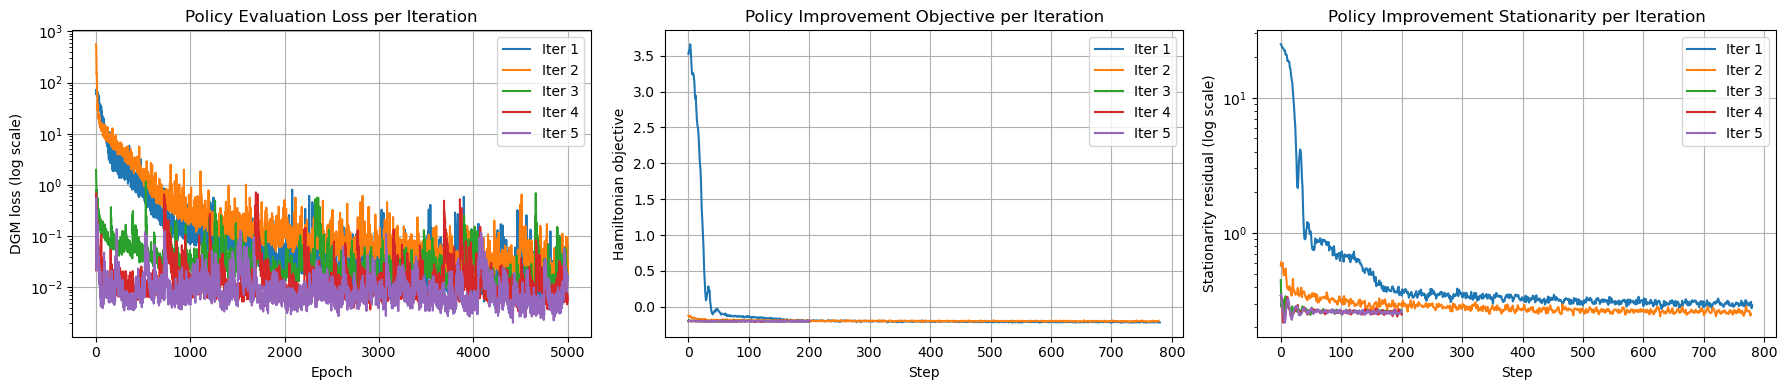

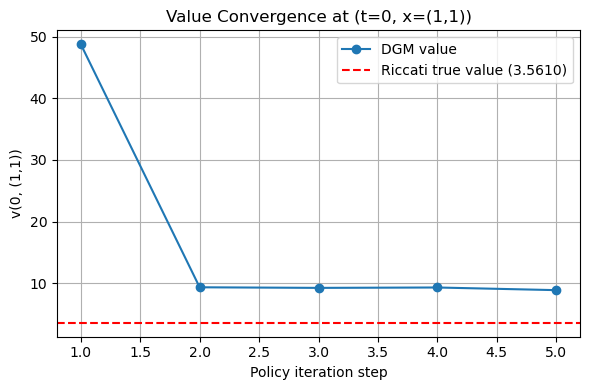

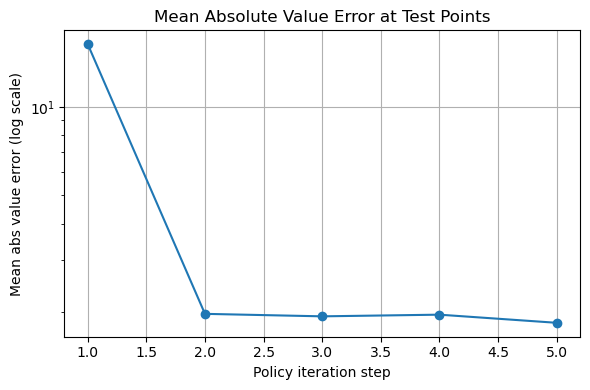

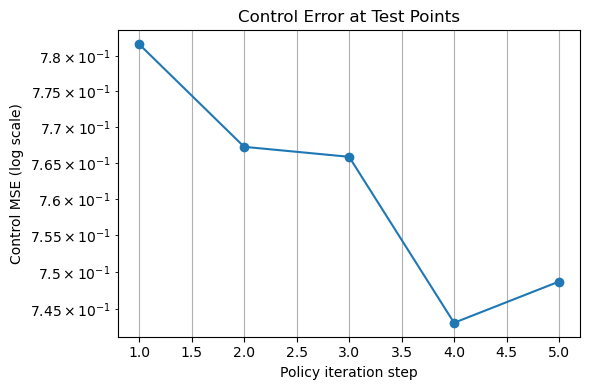

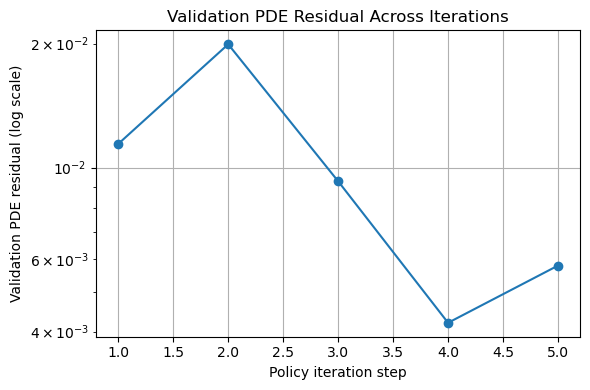

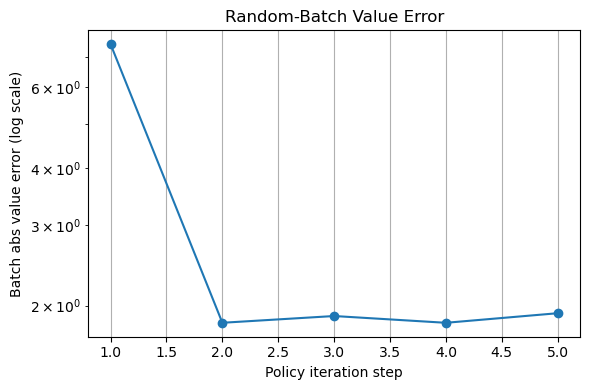

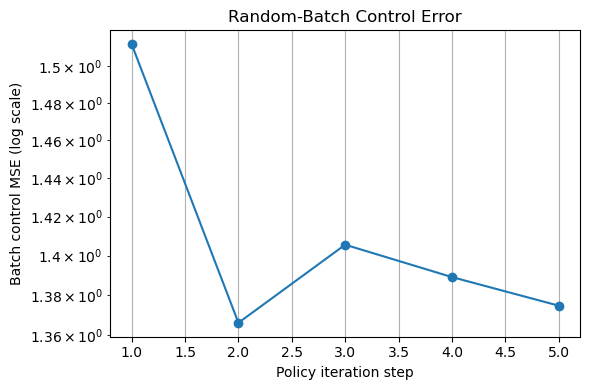


Best model came from iteration 4.
Best batch value error: 1.833676e+00

Done. Plots saved.


In [14]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------

torch.manual_seed(42)
np.random.seed(42)

# ---------------------------------------------------------------------------
# Network architectures
# ---------------------------------------------------------------------------

class DGMNet(nn.Module):
    """
    Simple feedforward network with SiLU activations.
    Used for the value function: input (t, x) -> scalar.
    """
    def __init__(self, input_dim, hidden_dim, n_layers):
        super().__init__()
        self.input = nn.Linear(input_dim, hidden_dim)
        self.hidden = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers)]
        )
        self.output = nn.Linear(hidden_dim, 1)

    def activation(self, x):
        return x * torch.sigmoid(x)

    def forward(self, t, x):
        inp = torch.cat([t, x], dim=1)
        h = self.activation(self.input(inp))
        for layer in self.hidden:
            h = self.activation(layer(h))
        return self.output(h)


class PolicyNet(nn.Module):
    """
    Feedforward network with SiLU activations.
    Used for the control: input (t, x) -> action in R^m.
    """
    def __init__(self, input_dim, hidden_dim, n_layers, output_dim):
        super().__init__()
        self.input = nn.Linear(input_dim, hidden_dim)
        self.hidden = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers)]
        )
        self.output = nn.Linear(hidden_dim, output_dim)

    def activation(self, x):
        return x * torch.sigmoid(x)

    def forward(self, t, x):
        inp = torch.cat([t, x], dim=1)
        h = self.activation(self.input(inp))
        for layer in self.hidden:
            h = self.activation(layer(h))
        return self.output(h)


# ---------------------------------------------------------------------------
# Riccati ODE solver (analytical reference)
# ---------------------------------------------------------------------------

class LQRSolver:
    """
    Solves the LQR problem via the Riccati ODE.

    Dynamics:
        dX_t = (H X_t + M a_t) dt + sigma dW_t

    Cost:
        integral_t^T [x' C x + a' D a] ds + x(T)' R x(T)

    Value function:
        v(t,x) = x' S(t) x + integral_t^T tr(sigma sigma' S(r)) dr

    Optimal control:
        a*(t,x) = -D^{-1} M' S(t) x
    """
    def __init__(self, H, M, C, D, R, sigma, T):
        self.H = np.array(H, dtype=float)
        self.M = np.array(M, dtype=float)
        self.C = np.array(C, dtype=float)
        self.D = np.array(D, dtype=float)
        self.R = np.array(R, dtype=float)
        self.sigma = np.array(sigma, dtype=float)
        self.T = float(T)

        self.state_dim = self.H.shape[0]
        self.action_dim = self.M.shape[1]

        self.D_inv = np.linalg.inv(self.D)
        self.MD_invMT = self.M @ self.D_inv @ self.M.T

        self.S_interp = None
        self.integral_interp = None

    def _riccati_rhs(self, tau, S_flat):
        S = S_flat.reshape(self.state_dim, self.state_dim)
        dS = 2.0 * self.H.T @ S - S @ self.MD_invMT @ S + self.C
        return dS.reshape(-1)

    def solve_riccati(self, time_grid):
        if isinstance(time_grid, torch.Tensor):
            time_grid = time_grid.detach().cpu().numpy()
        time_grid = np.array(time_grid, dtype=float).reshape(-1)

        tau_grid = self.T - time_grid
        sol = solve_ivp(
            self._riccati_rhs,
            (0.0, self.T),
            self.R.reshape(-1),
            t_eval=tau_grid[::-1],
            method="RK45",
            rtol=1e-8,
            atol=1e-10,
        )
        if not sol.success:
            raise RuntimeError(f"Riccati solve failed: {sol.message}")

        S_values = sol.y[:, ::-1].T.reshape(-1, self.state_dim, self.state_dim)
        S_values = 0.5 * (S_values + np.transpose(S_values, (0, 2, 1)))

        kind_S = "cubic" if len(time_grid) >= 4 else "linear"
        self.S_interp = [
            [
                interp1d(
                    time_grid,
                    S_values[:, i, j],
                    kind=kind_S,
                    bounds_error=False,
                    fill_value="extrapolate",
                )
                for j in range(self.state_dim)
            ]
            for i in range(self.state_dim)
        ]

        ss = self.sigma @ self.sigma.T
        trace_vals = np.array([np.trace(ss @ S) for S in S_values], dtype=float)

        integral = np.zeros(len(time_grid), dtype=float)
        for i in range(len(time_grid) - 2, -1, -1):
            dt = time_grid[i + 1] - time_grid[i]
            integral[i] = integral[i + 1] + 0.5 * dt * (trace_vals[i] + trace_vals[i + 1])

        self.integral_interp = interp1d(
            time_grid,
            integral,
            kind="linear",
            bounds_error=False,
            fill_value="extrapolate",
        )
        return S_values

    def _get_S(self, t):
        if self.S_interp is None:
            raise RuntimeError("Call solve_riccati first.")

        is_torch = isinstance(t, torch.Tensor)
        t_np = t.detach().cpu().numpy() if is_torch else np.asarray(t, dtype=float)

        shape = t_np.shape
        t_flat = t_np.reshape(-1)

        S_out = np.zeros((len(t_flat), self.state_dim, self.state_dim), dtype=float)
        for i in range(self.state_dim):
            for j in range(self.state_dim):
                S_out[:, i, j] = self.S_interp[i][j](t_flat)

        S_out = S_out.reshape(*shape, self.state_dim, self.state_dim)

        if is_torch:
            return torch.as_tensor(S_out, dtype=t.dtype, device=t.device)
        return S_out

    def value_function(self, t_batch, x_batch):
        if t_batch.ndim == 2 and t_batch.shape[1] == 1:
            t_batch = t_batch.squeeze(1)

        if x_batch.ndim == 3:
            x = x_batch.squeeze(1)
        else:
            x = x_batch

        S = self._get_S(t_batch)
        xSx = torch.sum((x.unsqueeze(1) @ S).squeeze(1) * x, dim=1)

        integral_np = self.integral_interp(t_batch.detach().cpu().numpy())
        integral = torch.as_tensor(integral_np, dtype=t_batch.dtype, device=t_batch.device)

        return (xSx + integral).unsqueeze(1)

    def optimal_control(self, t_batch, x_batch):
        if t_batch.ndim == 2 and t_batch.shape[1] == 1:
            t_batch = t_batch.squeeze(1)

        if x_batch.ndim == 3:
            x = x_batch.squeeze(1)
        else:
            x = x_batch

        S = self._get_S(t_batch)

        neg_DinvMT = torch.as_tensor(
            -self.D_inv @ self.M.T, dtype=t_batch.dtype, device=t_batch.device
        )  # (action_dim, state_dim)

        Sx = (S @ x.unsqueeze(2)).squeeze(2)  # (batch, state_dim)
        a = (neg_DinvMT @ Sx.unsqueeze(2)).squeeze(2)  # (batch, action_dim)
        return a


# ---------------------------------------------------------------------------
# Deep Galerkin solver (policy evaluation step)
# ---------------------------------------------------------------------------

class DeepGalerkinSolver:
    """
    Solves the linear PDE associated with a fixed policy via the DGM loss.

    Given a policy network a(t,x; theta_act), the value function u(t,x)
    satisfies the linear PDE:

        u_t + 1/2 tr(sigma sigma' u_xx)
            + (grad u)' (H x + M a)
            + x' C x + a' D a = 0

        u(T,x) = x' R x
    """
    def __init__(self, H, M, C, D, R, sigma, T, hidden_dim, n_layers, device):
        self.device = device
        self.T = float(T)

        self.H = torch.tensor(H, dtype=torch.float32, device=device)
        self.M = torch.tensor(M, dtype=torch.float32, device=device)
        self.C = torch.tensor(C, dtype=torch.float32, device=device)
        self.D = torch.tensor(D, dtype=torch.float32, device=device)
        self.R = torch.tensor(R, dtype=torch.float32, device=device)
        self.sigma = torch.tensor(sigma, dtype=torch.float32, device=device)

        self.state_dim = self.H.shape[0]
        self.action_dim = self.M.shape[1]

        self.net = DGMNet(self.state_dim + 1, hidden_dim, n_layers).to(device)
        self.optimizer = optim.Adam(self.net.parameters(), lr=1e-3)

        self.policy_net = None

    def warm_start(self, state_dict):
        self.net.load_state_dict(state_dict)
        self.optimizer = optim.Adam(self.net.parameters(), lr=1e-3)

    def pde_residual(self, t, x):
        t = t.detach().requires_grad_(True)
        x = x.detach().requires_grad_(True)

        u = self.net(t, x)

        u_t = torch.autograd.grad(
            u, t, grad_outputs=torch.ones_like(u), create_graph=True
        )[0]

        grad_u = torch.autograd.grad(
            u, x, grad_outputs=torch.ones_like(u), create_graph=True
        )[0]

        hessian_cols = []
        for i in range(self.state_dim):
            grad_i = torch.autograd.grad(
                grad_u[:, i],
                x,
                grad_outputs=torch.ones_like(grad_u[:, i]),
                create_graph=True,
            )[0]
            hessian_cols.append(grad_i)
        hessian = torch.stack(hessian_cols, dim=2)  # (batch, state_dim, state_dim)

        sigma_sigmaT = self.sigma @ self.sigma.T
        diffusion = 0.5 * torch.einsum("ij,bji->b", sigma_sigmaT, hessian)

        Hx = x @ self.H.T
        a = self.policy_net(t, x)
        Ma = a @ self.M.T

        drift_term = (grad_u * (Hx + Ma)).sum(dim=1)
        quad_x = torch.einsum("bi,ij,bj->b", x, self.C, x)
        quad_a = torch.einsum("bi,ij,bj->b", a, self.D, a)

        residual = u_t.squeeze(1) + diffusion + drift_term + quad_x + quad_a
        return residual

    def loss(self, batch_size):
        t = torch.rand(batch_size, 1, device=self.device) * self.T
        x = torch.randn(batch_size, self.state_dim, device=self.device)

        res = self.pde_residual(t, x)
        pde_loss = torch.mean(res ** 2)

        x_T = torch.randn(batch_size, self.state_dim, device=self.device)
        t_T = torch.ones(batch_size, 1, device=self.device) * self.T
        u_T = self.net(t_T, x_T)
        target = torch.einsum("bi,ij,bj->b", x_T, self.R, x_T)
        terminal_loss = torch.mean((u_T.squeeze(1) - target) ** 2)

        return pde_loss + terminal_loss

    def validation_pde_residual(self, batch_size=1024):
        with torch.enable_grad():
            t = torch.rand(batch_size, 1, device=self.device) * self.T
            x = torch.randn(batch_size, self.state_dim, device=self.device)
            res = self.pde_residual(t, x)
            return torch.mean(res ** 2).item()

    def train(self, epochs=5000, batch_size=256):
        self.loss_history = []
        for epoch in range(epochs):
            self.optimizer.zero_grad()
            loss = self.loss(batch_size)
            loss.backward()
            self.optimizer.step()
            self.loss_history.append(loss.item())

            if epoch % 500 == 499:
                print(f"  [Policy eval] Epoch {epoch+1:5d} | Loss: {loss.item():.6f}")

        return self.loss_history


# ---------------------------------------------------------------------------
# Policy improvement step
# ---------------------------------------------------------------------------

def compute_hamiltonian_objective(
    val_net,
    act_net,
    M,
    D,
    T,
    state_dim,
    batch_size=256,
    device="cpu",
    normalize_grad=True,
    action_reg=1e-3,
):
    """
    Control-dependent part of the Hamiltonian:
        H_a = (grad_v)' M a + a' D a

    Optional gradient normalization is used to stabilize policy improvement.
    A small action regularization term is added for robustness.
    """
    t = torch.rand((batch_size, 1), device=device) * T
    x = torch.randn((batch_size, state_dim), device=device)
    x.requires_grad_(True)

    v = val_net(t, x)
    grad_v = torch.autograd.grad(
        v, x, grad_outputs=torch.ones_like(v), create_graph=False
    )[0].detach()

    if normalize_grad:
        grad_v = grad_v / (grad_v.norm(dim=1, keepdim=True) + 1e-6)

    a = act_net(t, x.detach())

    linear_term = (grad_v @ M.T * a).sum(dim=1)
    quad_term = torch.einsum("bi,ij,bj->b", a, D, a)
    reg_term = action_reg * torch.sum(a ** 2, dim=1)

    return (linear_term + quad_term + reg_term).mean()


def compute_policy_stationarity_loss(
    val_net,
    act_net,
    M,
    D,
    T,
    state_dim,
    batch_size=256,
    device="cpu",
    normalize_grad=True,
):
    """
    First-order optimality residual for:
        H(a) = (grad_v)' M a + a' D a

    FOC:
        M' grad_v + 2 D a = 0

    Returns:
        E[ ||M' grad_v + 2 D a||^2 ]
    """
    t = torch.rand((batch_size, 1), device=device) * T
    x = torch.randn((batch_size, state_dim), device=device)
    x.requires_grad_(True)

    v = val_net(t, x)
    grad_v = torch.autograd.grad(
        v, x, grad_outputs=torch.ones_like(v), create_graph=False
    )[0].detach()

    if normalize_grad:
        grad_v = grad_v / (grad_v.norm(dim=1, keepdim=True) + 1e-6)

    a = act_net(t, x.detach())

    foc = grad_v @ M + 2.0 * (a @ D.T)
    return torch.mean(torch.sum(foc ** 2, dim=1))


def policy_improvement(
    val_net,
    act_net,
    M,
    D,
    T,
    state_dim,
    batch_size=256,
    device="cpu",
    lr=1e-3,
    n_steps=1000,
    normalize_grad=True,
    action_reg=1e-3,
    early_stop_patience=150,
    early_stop_tol=1e-4,
):
    """
    Update act_net to minimize the control-dependent Hamiltonian.

    Improvements:
    - stronger LR than the stalled run
    - gradient normalization
    - small action regularization
    - best-state restore
    - early stopping on stationarity stagnation
    """
    optimizer = optim.Adam(act_net.parameters(), lr=lr)
    val_net.eval()

    ham_objective_history = []
    stationarity_history = []

    best_stationarity = float("inf")
    best_act_state = None
    steps_since_improvement = 0

    for step in range(n_steps):
        optimizer.zero_grad()

        objective = compute_hamiltonian_objective(
            val_net=val_net,
            act_net=act_net,
            M=M,
            D=D,
            T=T,
            state_dim=state_dim,
            batch_size=batch_size,
            device=device,
            normalize_grad=normalize_grad,
            action_reg=action_reg,
        )
        objective.backward()
        optimizer.step()

        stationarity = compute_policy_stationarity_loss(
            val_net=val_net,
            act_net=act_net,
            M=M,
            D=D,
            T=T,
            state_dim=state_dim,
            batch_size=batch_size,
            device=device,
            normalize_grad=normalize_grad,
        )

        obj_val = objective.item()
        stat_val = stationarity.item()

        ham_objective_history.append(obj_val)
        stationarity_history.append(stat_val)

        if stat_val < best_stationarity - early_stop_tol:
            best_stationarity = stat_val
            best_act_state = {
                k: v.detach().cpu().clone()
                for k, v in act_net.state_dict().items()
            }
            steps_since_improvement = 0
        else:
            steps_since_improvement += 1

        if step % 100 == 99:
            print(
                f"  [Policy impr] Step {step+1:4d} | "
                f"Ham objective: {obj_val:.6f} | "
                f"Stationarity: {stat_val:.6f} | "
                f"Best stat: {best_stationarity:.6f}"
            )

        if step >= 200 and steps_since_improvement >= early_stop_patience:
            print(
                f"  [Policy impr] Early stopping at step {step+1} "
                f"(no meaningful stationarity improvement for {early_stop_patience} steps)."
            )
            break

    if best_act_state is not None:
        act_net.load_state_dict(best_act_state)

    return act_net, ham_objective_history, stationarity_history


# ---------------------------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------------------------

def compute_test_diagnostics(val_net, act_net, lqr_solver, t_test, x_test):
    with torch.no_grad():
        v_pred = val_net(t_test, x_test)
        a_pred = act_net(t_test, x_test)

        v_true = lqr_solver.value_function(t_test, x_test)
        a_true = lqr_solver.optimal_control(t_test, x_test)

        value_abs_err = torch.abs(v_pred - v_true).mean().item()
        value_rel_err = (
            torch.abs(v_pred - v_true) / (torch.abs(v_true) + 1e-8)
        ).mean().item()
        control_mse = torch.mean((a_pred - a_true) ** 2).item()

    return {
        "v_pred": v_pred.cpu().numpy(),
        "a_pred": a_pred.cpu().numpy(),
        "v_true": v_true.cpu().numpy(),
        "a_true": a_true.cpu().numpy(),
        "value_abs_err": value_abs_err,
        "value_rel_err": value_rel_err,
        "control_mse": control_mse,
    }


def evaluate_random_batch(val_net, act_net, lqr_solver, T, state_dim, batch_size=1024, device="cpu"):
    with torch.no_grad():
        t = torch.rand(batch_size, 1, device=device) * T
        x = torch.randn(batch_size, state_dim, device=device)

        v_pred = val_net(t, x)
        a_pred = act_net(t, x)

        v_true = lqr_solver.value_function(t, x)
        a_true = lqr_solver.optimal_control(t, x)

        value_abs_err = torch.mean(torch.abs(v_pred - v_true)).item()
        value_rel_err = torch.mean(torch.abs(v_pred - v_true) / (torch.abs(v_true) + 1e-8)).item()
        control_mse = torch.mean((a_pred - a_true) ** 2).item()

    return {
        "batch_value_abs_err": value_abs_err,
        "batch_value_rel_err": value_rel_err,
        "batch_control_mse": control_mse,
    }


# ---------------------------------------------------------------------------
# Policy iteration loop
# ---------------------------------------------------------------------------

def policy_iteration(
    H,
    M,
    C,
    D,
    R,
    sigma,
    T,
    hidden_dim,
    n_layers,
    n_iter,
    epochs_eval,
    epochs_impr,
    batch_size,
    device,
    lqr_solver=None,
):
    state_dim = H.shape[0]
    action_dim = M.shape[1]

    t_test = torch.tensor([[0.0], [0.5], [1.0]], dtype=torch.float32, device=device)
    x_test = torch.tensor(
        [[1.0, 1.0], [0.5, -0.5], [0.0, 0.0]],
        dtype=torch.float32,
        device=device,
    )

    history = {
        "eval_loss": [],
        "ham_objective": [],
        "stationarity_loss": [],
        "value_at_test": [],
        "ctrl_at_test": [],
        "value_true_at_test": [],
        "ctrl_true_at_test": [],
        "value_err": [],
        "value_rel_err": [],
        "control_mse": [],
        "validation_pde_residual": [],
        "batch_value_abs_err": [],
        "batch_value_rel_err": [],
        "batch_control_mse": [],
    }

    best_models = {
        "best_metric": float("inf"),
        "best_iteration": None,
        "best_value_net_state": None,
        "best_policy_net_state": None,
    }

    act_net = PolicyNet(
        input_dim=state_dim + 1,
        hidden_dim=hidden_dim,
        n_layers=n_layers,
        output_dim=action_dim,
    ).to(device)

    with torch.no_grad():
        if action_dim == 2:
            act_net.output.bias.data = torch.tensor(
                [1.0, 1.0], dtype=torch.float32, device=device
            )
        else:
            act_net.output.bias.data = torch.ones(
                action_dim, dtype=torch.float32, device=device
            )

    prev_val_state = None
    final_solver = None

    for it in range(n_iter):
        print(f"\n{'='*70}")
        print(f"  Policy iteration step {it+1} / {n_iter}")
        print(f"{'='*70}")

        # ---------------------------------------------------------------
        # Step 1: Policy evaluation
        # ---------------------------------------------------------------
        solver = DeepGalerkinSolver(
            H, M, C, D, R, sigma, T, hidden_dim, n_layers, device
        )

        if prev_val_state is not None:
            print("  Warm-starting value network from previous iteration.")
            solver.warm_start(prev_val_state)

        solver.policy_net = act_net

        for p in act_net.parameters():
            p.requires_grad_(False)

        eval_loss = solver.train(epochs=epochs_eval, batch_size=batch_size)
        history["eval_loss"].append(eval_loss)

        prev_val_state = {
            k: v.detach().cpu().clone()
            for k, v in solver.net.state_dict().items()
        }

        val_residual = solver.validation_pde_residual(batch_size=1024)
        history["validation_pde_residual"].append(val_residual)

        for p in act_net.parameters():
            p.requires_grad_(True)

        # ---------------------------------------------------------------
        # Step 2: Policy improvement
        # ---------------------------------------------------------------
        act_net, ham_hist, stat_hist = policy_improvement(
            val_net=solver.net,
            act_net=act_net,
            M=solver.M,
            D=solver.D,
            T=T,
            state_dim=state_dim,
            batch_size=batch_size,
            device=device,
            lr=1e-3,
            n_steps=epochs_impr,
            normalize_grad=True,
            action_reg=1e-3,
            early_stop_patience=150,
            early_stop_tol=1e-4,
        )

        history["ham_objective"].append(ham_hist)
        history["stationarity_loss"].append(stat_hist)

        # ---------------------------------------------------------------
        # Diagnostics
        # ---------------------------------------------------------------
        with torch.no_grad():
            v_pred = solver.net(t_test, x_test).cpu().numpy()
            a_pred = act_net(t_test, x_test).cpu().numpy()

        history["value_at_test"].append(v_pred)
        history["ctrl_at_test"].append(a_pred)

        print(f"\n  Diagnostics after iteration {it+1}:")

        if lqr_solver is not None:
            diag = compute_test_diagnostics(solver.net, act_net, lqr_solver, t_test, x_test)

            history["value_true_at_test"].append(diag["v_true"])
            history["ctrl_true_at_test"].append(diag["a_true"])
            history["value_err"].append(diag["value_abs_err"])
            history["value_rel_err"].append(diag["value_rel_err"])
            history["control_mse"].append(diag["control_mse"])

            batch_diag = evaluate_random_batch(
                solver.net, act_net, lqr_solver, T, state_dim, batch_size=1024, device=device
            )
            history["batch_value_abs_err"].append(batch_diag["batch_value_abs_err"])
            history["batch_value_rel_err"].append(batch_diag["batch_value_rel_err"])
            history["batch_control_mse"].append(batch_diag["batch_control_mse"])

            for i in range(t_test.shape[0]):
                t_i = t_test[i, 0].item()
                x_i = x_test[i].cpu().numpy()
                v_i = diag["v_pred"][i, 0]
                a_i = diag["a_pred"][i]
                v_true_i = diag["v_true"][i, 0]
                a_true_i = diag["a_true"][i]

                print(
                    f"    t={t_i:.1f}, x={x_i} | "
                    f"v={v_i:.6f} (true={v_true_i:.6f}, err={abs(v_i-v_true_i):.6f}) | "
                    f"a={np.round(a_i, 4)} (true={np.round(a_true_i, 4)})"
                )

            print(f"    Mean abs value error   : {diag['value_abs_err']:.6e}")
            print(f"    Mean rel value error   : {diag['value_rel_err']:.6e}")
            print(f"    Mean control MSE       : {diag['control_mse']:.6e}")
            print(f"    Validation PDE residual: {val_residual:.6e}")
            print(f"    Batch abs value error  : {batch_diag['batch_value_abs_err']:.6e}")
            print(f"    Batch rel value error  : {batch_diag['batch_value_rel_err']:.6e}")
            print(f"    Batch control MSE      : {batch_diag['batch_control_mse']:.6e}")

            # Best-model tracking by random-batch value error
            current_metric = batch_diag["batch_value_abs_err"]
            if current_metric < best_models["best_metric"]:
                best_models["best_metric"] = current_metric
                best_models["best_iteration"] = it + 1
                best_models["best_value_net_state"] = copy.deepcopy(solver.net.state_dict())
                best_models["best_policy_net_state"] = copy.deepcopy(act_net.state_dict())
                print(f"    New best model saved at iteration {it+1}.")
        else:
            for i in range(t_test.shape[0]):
                t_i = t_test[i, 0].item()
                x_i = x_test[i].cpu().numpy()
                v_i = v_pred[i, 0]
                a_i = a_pred[i]
                print(f"    t={t_i:.1f}, x={x_i} | v={v_i:.6f} | a={np.round(a_i, 4)}")

            print(f"    Validation PDE residual: {val_residual:.6e}")

        final_solver = solver

    # Restore best model if available
    if best_models["best_value_net_state"] is not None:
        print(f"\nRestoring best model from iteration {best_models['best_iteration']}.")
        final_solver.net.load_state_dict(best_models["best_value_net_state"])
        act_net.load_state_dict(best_models["best_policy_net_state"])

    return final_solver.net, act_net, history, best_models


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_history(history, n_iter, out_dir, lqr_solver=None):
    os.makedirs(out_dir, exist_ok=True)

    # -------------------------------------------------------------------
    # 1. Loss curves
    # -------------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    ax = axes[0]
    for k, loss in enumerate(history["eval_loss"]):
        ax.semilogy(loss, label=f"Iter {k+1}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("DGM loss (log scale)")
    ax.set_title("Policy Evaluation Loss per Iteration")
    ax.legend()
    ax.grid(True)

    ax = axes[1]
    for k, loss in enumerate(history["ham_objective"]):
        ax.plot(loss, label=f"Iter {k+1}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Hamiltonian objective")
    ax.set_title("Policy Improvement Objective per Iteration")
    ax.legend()
    ax.grid(True)

    ax = axes[2]
    for k, loss in enumerate(history["stationarity_loss"]):
        ax.semilogy(loss, label=f"Iter {k+1}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Stationarity residual (log scale)")
    ax.set_title("Policy Improvement Stationarity per Iteration")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "policy_iteration_losses.png"), dpi=150)
    plt.show()

    # -------------------------------------------------------------------
    # 2. Value convergence at (t=0, x=(1,1))
    # -------------------------------------------------------------------
    v_at_11 = [history["value_at_test"][k][0, 0] for k in range(n_iter)]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(range(1, n_iter + 1), v_at_11, "o-", label="DGM value")

    if lqr_solver is not None:
        t0_ref = torch.tensor([0.0], dtype=torch.float32)
        x0_ref = torch.tensor([[1.0, 1.0]], dtype=torch.float32)
        v_true = lqr_solver.value_function(t0_ref, x0_ref).item()
        ax.axhline(v_true, color="red", linestyle="--", label=f"Riccati true value ({v_true:.4f})")

    ax.set_xlabel("Policy iteration step")
    ax.set_ylabel("v(0, (1,1))")
    ax.set_title("Value Convergence at (t=0, x=(1,1))")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "policy_iteration_value_convergence.png"), dpi=150)
    plt.show()

    # -------------------------------------------------------------------
    # 3. Mean absolute value error
    # -------------------------------------------------------------------
    if len(history["value_err"]) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.semilogy(range(1, n_iter + 1), history["value_err"], "o-")
        ax.set_xlabel("Policy iteration step")
        ax.set_ylabel("Mean abs value error (log scale)")
        ax.set_title("Mean Absolute Value Error at Test Points")
        ax.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "policy_iteration_value_error.png"), dpi=150)
        plt.show()

    # -------------------------------------------------------------------
    # 4. Mean control MSE
    # -------------------------------------------------------------------
    if len(history["control_mse"]) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.semilogy(range(1, n_iter + 1), history["control_mse"], "o-")
        ax.set_xlabel("Policy iteration step")
        ax.set_ylabel("Control MSE (log scale)")
        ax.set_title("Control Error at Test Points")
        ax.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "policy_iteration_control_mse.png"), dpi=150)
        plt.show()

    # -------------------------------------------------------------------
    # 5. Validation PDE residual
    # -------------------------------------------------------------------
    if len(history["validation_pde_residual"]) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.semilogy(range(1, n_iter + 1), history["validation_pde_residual"], "o-")
        ax.set_xlabel("Policy iteration step")
        ax.set_ylabel("Validation PDE residual (log scale)")
        ax.set_title("Validation PDE Residual Across Iterations")
        ax.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "policy_iteration_validation_pde_residual.png"), dpi=150)
        plt.show()

    # -------------------------------------------------------------------
    # 6. Random-batch value error
    # -------------------------------------------------------------------
    if len(history["batch_value_abs_err"]) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.semilogy(range(1, n_iter + 1), history["batch_value_abs_err"], "o-")
        ax.set_xlabel("Policy iteration step")
        ax.set_ylabel("Batch abs value error (log scale)")
        ax.set_title("Random-Batch Value Error")
        ax.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "policy_iteration_batch_value_error.png"), dpi=150)
        plt.show()

    # -------------------------------------------------------------------
    # 7. Random-batch control MSE
    # -------------------------------------------------------------------
    if len(history["batch_control_mse"]) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.semilogy(range(1, n_iter + 1), history["batch_control_mse"], "o-")
        ax.set_xlabel("Policy iteration step")
        ax.set_ylabel("Batch control MSE (log scale)")
        ax.set_title("Random-Batch Control Error")
        ax.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "policy_iteration_batch_control_mse.png"), dpi=150)
        plt.show()


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    # Writable output directory
    out_dir = "outputs"
    os.makedirs(out_dir, exist_ok=True)

    # Problem matrices
    H = np.array([[0.5, 0.1], [0.1, 0.3]])
    M = np.array([[1.0, 0.5], [0.0, 1.0]])
    C = np.array([[2.0, 0.5], [0.5, 1.0]])
    D = np.array([[2.0, 0.0], [0.0, 1.0]])
    R = np.array([[1.0, 0.0], [0.0, 2.0]])
    sigma = np.array([[0.3, 0.1], [0.0, 0.2]])
    T = 1.0

    # Hyperparameters
    hidden_dim = 64
    n_layers = 4
    n_iter = 5
    epochs_eval = 5000
    epochs_impr = 1000
    batch_size = 256

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Riccati reference solution
    lqr = LQRSolver(H, M, C, D, R, sigma, T)
    time_grid = np.linspace(0.0, T, 1000)
    lqr.solve_riccati(time_grid)

    S_T = lqr._get_S(np.array([T]))[0]
    print(f"Riccati terminal error ||S(T) - R|| = {np.linalg.norm(S_T - R):.2e}")

    # Run policy iteration
    val_net, act_net, history, best_models = policy_iteration(
        H=H,
        M=M,
        C=C,
        D=D,
        R=R,
        sigma=sigma,
        T=T,
        hidden_dim=hidden_dim,
        n_layers=n_layers,
        n_iter=n_iter,
        epochs_eval=epochs_eval,
        epochs_impr=epochs_impr,
        batch_size=batch_size,
        device=device,
        lqr_solver=lqr,
    )

    # Plots
    plot_history(history, n_iter, out_dir=out_dir, lqr_solver=lqr)

    if best_models["best_iteration"] is not None:
        print(f"\nBest model came from iteration {best_models['best_iteration']}.")
        print(f"Best batch value error: {best_models['best_metric']:.6e}")

    print("\nDone. Plots saved.")